# Noisy entanglement as a resource — Werner pairs, twirling, distillation, repeaters and certification

**Marcin Płodzień** — Institute of Theoretical Physics, Jagiellonian University in Kraków  
[ORCID 0000-0002-0835-1644](https://orcid.org/0000-0002-0835-1644) · [github.com/MarcinPlodzien](https://github.com/MarcinPlodzien) · [www](https://chaos.if.uj.edu.pl/marcinplodzien/)

*Quantum Many-Body Simulation — Chapter 14 — Quantum communication and cryptography*

## 1. Introduction and motivation

Teleportation, entanglement swapping and entanglement-based key distribution all consume shared Bell pairs
$\vert\Phi^+\rangle=(\vert00\rangle+\vert11\rangle)/\sqrt2$, and every derivation in chapter 8 and in
[notebook 53](../ch14_quantum_communication_and_cryptography/53_quantum_key_distribution.ipynb) began with a perfect
one. Real pairs are never perfect. Photons that carry the two halves are absorbed in the fibre, the qubits decohere
while they wait in memories, the source is imperfect, and Eve may tamper with the pairs on their way. The pairs that
Alice and Bob actually hold are mixed states with a fidelity $F=\langle\Phi^+\vert\rho\vert\Phi^+\rangle$ below one.
Noise of this kind is fatal for two tasks. Over long distances the pairs must be joined by swapping, and each swap
multiplies the noise of the links. And for secret keys the noise is the room that Eve may occupy: a pair with
$F<1$ may be correlated with a system in her hands.

**The idea.** Noisy pairs are still a resource, if Alice and Bob process them with local operations and classical
communication. Four tools turn them into good pairs over long distances. **Twirling**, a random local rotation,
brings any pair into a standard form with a single parameter, the Werner form. **Distillation** consumes several
noisy pairs to produce fewer pairs of higher fidelity. **Quantum repeaters** cut a long line into short segments,
distil each segment and join the segments by swapping, so that the noise and the loss of the long fibre never act
at once. **Certification** tests a random sample of the delivered pairs with local measurements and bounds the
fidelity of the rest, even when the source is controlled by Eve.

![Noisy links between Alice, a repeater node R and Bob are distilled into better pairs, joined by a Bell measurement at R into one long pair, distilled again, and certified by testing a random sample of the pairs](figures/repeater_chain.svg)

**Figure 1.** The tools of this notebook in one line of communication. (1) Each short segment produces noisy pairs,
Werner pairs of fidelity $F_0$, which wait in quantum memories (Section 3). (2) Distillation turns two pairs of a
segment into one better pair (Section 7). (3) A Bell measurement at the repeater node R swaps the entanglement into
one pair between Alice and Bob; the noise of the two links adds up (Section 8). (4) Further distillation repairs the
long pair, and a test of a random sample with the correlations $XX$, $YY$ and $ZZ$ bounds the fidelity of the pairs
that are kept (Section 9).

### 1.1 Road map

* **Section 3** recalls Werner pairs and derives what happens when both halves of a pair are depolarised.
* **Section 4** shows that teleportation through a Werner pair is a depolarising channel, by linearity and with the
  engine's teleportation circuit.
* **Section 5** derives twirling: the invariance of $\vert\Phi^+\rangle$ under $U\otimes U^*$ and the twirl with the
  24 Clifford gates, which maps every pair to the Werner pair of the same fidelity.
* **Section 6** gives Eve the purification of the pair and computes her information about the key bits as a
  function of the fidelity.
* **Section 7** derives the distillation step of Bennett and coauthors from the bilateral CNOT, runs it on density
  tensors and shot by shot, and iterates it.
* **Section 8** turns to distance: fibre loss, the bound for direct transmission, swapping with noisy links, and a
  toy repeater chain compared with direct transmission.
* **Section 9** certifies pairs: the fidelity from three local correlations, Hoeffding's confidence bound, and an
  adversarial source defeated by random sampling.

### What you will learn

*Physics and information*

* why a Werner pair is the natural noise model, and why depolarising both halves multiplies the visibilities;
* why teleportation through a Werner pair is the depolarising channel, and when it beats the classical $2/3$;
* how a random local rotation brings any pair into Werner form without changing its fidelity, and what twirling
  cannot do;
* why the worst case is that Eve holds the purification, and how much she then knows about the key;
* how the bilateral CNOT compares parities of two pairs, why one distillation step raises the fidelity for $F>1/2$,
  and what it costs;
* why fibre loss limits direct transmission, and how swapping and distillation on short segments change the scaling
  of the rate with distance;
* how three local correlations give the fidelity, and why the test sample must be chosen at random after delivery.

*Numerical methods*

* channels and protocols on two-, three- and four-qubit density tensors, with projectors for postselection;
* group averages as `jax.vmap` over a stack of gates;
* shot-by-shot Monte Carlo of a postselected protocol, with binomial error bars;
* Monte Carlo checks of confidence bounds: the empirical failure rate against the promised $\delta$.

*Implementation practice*

* every formula checked against an engine computation, with `assert`;
* wrong controls that must fail: a dephased resource in teleportation, the $U\otimes U$ twirl, the Pauli-only
  twirl, distillation without postselection, a source with only $Z$ correlations, and fixed test positions.

### Prerequisites

* [Notebook 19](../ch08_quantum_information_protocols/19_bell_states_and_chsh.ipynb): Bell states and their
  correlations (Sections 3–4), Werner states with visibility $v$ and their entanglement and CHSH thresholds
  (Section 11).
* [Notebook 20](../ch08_quantum_information_protocols/20_quantum_teleportation.ipynb): the teleportation circuit
  (Section 4), the classical benchmark $2/3$ (Section 8) and teleportation through a noisy pair (Section 10).
* [Notebook 21](../ch08_quantum_information_protocols/21_entanglement_swapping_and_superdense_coding.ipynb): the Bell
  measurement (Section 3), Werner states as random Pauli errors and the swapping rule (Section 10), and the decay of a
  chain without distillation (Section 11).
* [Notebook 52](../ch14_quantum_communication_and_cryptography/52_quantum_rules_channels_and_capacities.ipynb):
  monogamy and purification (Section 6.2), the Holevo quantity (Section 9.1), and the depolarising channel
  (Section 8.2).
* [Notebook 53](../ch14_quantum_communication_and_cryptography/53_quantum_key_distribution.ipynb): bit and phase
  errors, the conditional entropy with quantum side information and the key thresholds of Werner pairs
  (Sections 7.1–7.5).
* [Notebook 07](../ch03_matrix_free_engine/07_density_matrices_and_quantum_channels.ipynb): density tensors, partial
  traces and Kraus channels.

## Configuration

Every notebook of this course starts with the same cell. Choose where to run (`DEVICE`) and the floating-point precision (`PRECISION`): `"double"` = `float64/complex128` (default, recommended for physics), `"single"` = `float32/complex64` (half the memory, faster on consumer GPUs, but watch the round-off). All code below derives its dtypes from `RDTYPE`/`CDTYPE` and its check tolerances from `TOL`, so nothing else needs to change.

In [1]:
# ==============================================================================
# CONFIGURATION  -- adapt to your hardware, then run the notebook top to bottom
# ==============================================================================
DEVICE    = "auto"     # "auto": use a GPU if JAX finds one, else CPU | "cpu" | "gpu"
PRECISION = "double"   # "double": float64/complex128 | "single": float32/complex64

import os
if DEVICE == "cpu":
    os.environ["JAX_PLATFORMS"] = "cpu"          # must be set BEFORE jax is imported

import os
import string
from functools import partial

import math
import numpy as np
import jax
import jax.numpy as jnp
from jax import lax

# Precision is configurable: "double" = float64/complex128 (default; needed for long time evolutions and
# tight validation), "single" = float32/complex64 (half the memory, faster on consumer GPUs).
# In a notebook PRECISION is defined in the Configuration cell; for this module use the env var QE_PRECISION.
PRECISION = globals().get("PRECISION", os.environ.get("QE_PRECISION", "double"))
jax.config.update("jax_enable_x64", PRECISION == "double")
RDTYPE = jnp.float64 if PRECISION == "double" else jnp.float32       # real dtype
CDTYPE = jnp.complex128 if PRECISION == "double" else jnp.complex64  # complex dtype of all states/operators
TOL = 1e-10 if PRECISION == "double" else 1e-4                       # tolerance for sanity checks (asserts)
_LETTERS = string.ascii_letters  # 52 einsum labels; a call needs (axes + new labels) <= 52: apply_gate on a state
                                 # N + k <= 52 (N <= 51 for k = 1), apply_gate_dm 2N + k <= 52 (N <= 25 for k = 1, 2),
                                 # apply_kraus_dm 2N + 2k + 1 <= 52 (N <= 24 for k = 1, N <= 23 for k = 2)

import time
import matplotlib.pyplot as plt

if DEVICE == "gpu" and jax.default_backend() == "cpu":
    print("WARNING: DEVICE='gpu' requested but JAX found no GPU -- running on CPU.")
print(f"JAX {jax.__version__} | backend: {jax.default_backend()} | devices: {jax.devices()}")
print(f"precision: {PRECISION} -> real {RDTYPE.__name__}, complex {CDTYPE.__name__}, check tolerance TOL={TOL:g}")


JAX 0.11.0 | backend: cpu | devices: [CpuDevice(id=0)]
precision: double -> real float64, complex complex128, check tolerance TOL=1e-10


## 2. Engine recap and helpers

A pair of qubits is a density tensor of shape $(2,2,2,2)$, with two ket axes followed by two bra axes (notebook 07,
Section 5). Channels act with `apply_kraus_dm`, gates and projectors with `apply_gate_dm`, and partial traces with
`rdm_dm`. Four-qubit states, two pairs side by side, are tensors of rank eight. The helper cell defines the Bell
basis in the order $\Phi^+,\Phi^-,\Psi^+,\Psi^-$, the Werner pair, the fidelity with $\vert\Phi^+\rangle$ and the
weights of a state in the Bell basis. As in the earlier notebooks of the chapter, experiment $i$ draws its random
numbers from its own key `jax.random.fold_in(MASTER, i)`.

In [2]:
#| code-fold: true
#| code-summary: "Engine recap — the simulator primitives used in this notebook (click to expand)"
# ==============================================================================
# ENGINE RECAP: the functions of quantum_engine.py (SmoQ.jax) used in this notebook.
# Each one is derived, with its mathematics and an independent check, in notebook 08b
# (Chapter 3), 'Building the quantum simulator engine'.
# States are rank-N tensors of shape (2,)*N; every operator acts through ONE einsum.
# ==============================================================================
# ----------------------------------------------------------------------------
# 1. Elementary matrices: Paulis, Clifford generators, rotations
# ----------------------------------------------------------------------------
I2 = jnp.eye(2, dtype=CDTYPE)
X = jnp.array([[0, 1], [1, 0]], dtype=CDTYPE)
Y = jnp.array([[0, -1j], [1j, 0]], dtype=CDTYPE)
Z = jnp.array([[1, 0], [0, -1]], dtype=CDTYPE)
H = jnp.array([[1, 1], [1, -1]], dtype=CDTYPE) / jnp.sqrt(2.0)      # Hadamard: Z-basis <-> X-basis
S = jnp.array([[1, 0], [0, 1j]], dtype=CDTYPE)                      # phase gate, S^2 = Z
SDG = S.conj().T
P0 = jnp.array([[1, 0], [0, 0]], dtype=CDTYPE)  # projector |0><0|
P1 = jnp.array([[0, 0], [0, 1]], dtype=CDTYPE)  # projector |1><1|
PAULI = {"I": I2, "X": X, "Y": Y, "Z": Z}
CNOT = jnp.array([[1, 0, 0, 0], [0, 1, 0, 0], [0, 0, 0, 1], [0, 0, 1, 0]], dtype=CDTYPE)
def rx(theta):
    """Rotation about x:  Rx(theta) = exp(-i theta X/2) = cos(theta/2) 1 - i sin(theta/2) X.

    Derivation: for any operator with P^2 = 1 the exponential series splits into even/odd
    parts,  exp(-i a P) = cos(a) 1 - i sin(a) P.   Here a = theta/2.
    `theta` may be a traced JAX scalar, so the gate is differentiable (jax.grad) and jit-able.
    """
    c, s = jnp.cos(theta / 2), jnp.sin(theta / 2)
    return jnp.array([[c, -1j * s], [-1j * s, c]], dtype=CDTYPE)


# ----------------------------------------------------------------------------
# 2. THE core primitive: a k-qubit operator acting on a tensor through ONE einsum
# ----------------------------------------------------------------------------
def apply_gate(psi, U, qubits):
    """Apply a k-qubit operator U to the axes `qubits` of the tensor `psi`.

    MATH
    ----
    One qubit (k=1), target q:
        psi'[s_0,..,a,..,s_{N-1}] = sum_b  U[a,b] psi[s_0,..,b,..,s_{N-1}]
    Two qubits (k=2), targets (q1,q2); the 4x4 matrix is reshaped to U[a1,a2,b1,b2]:
        psi'[.., a1, .., a2, ..] = sum_{b1,b2} U[a1,a2,b1,b2] psi[.., b1, .., b2, ..]
    This IS the action of (1 x .. x U x .. x 1) -- written without ever building it.

    EINSUM TRANSLATION  (generated automatically below)
    ------------------
        N=3, q=1        :  "db,abc->adc"          d = new (output) index of qubit 1
        N=4, q=(1,3)    :  "efbd,abcd->aecf"      e,f = new indices of qubits 1 and 3
    Recipe: label the axes of psi with letters a,b,c,...; give every target qubit a NEW
    letter (the next unused ones); U carries (new letters)+(old letters of the targets); the
    output is psi's labels with the target letters replaced by the new ones.

    IMPLEMENTATION NOTES
    --------------------
    * reshape of U:  (2^k,2^k) -> (2,)*2k.  Row index = (a1..ak), column = (b1..bk), and
      the FIRST qubit in `qubits` is the most significant bit of the small matrix, i.e. it
      corresponds to the LEFT factor of kron(A,B).
    * `qubits` may be any distinct axes in any order: non-neighbouring gates cost the same.
    * U need not be unitary: projectors, Kraus operators and Hamiltonian terms reuse this.
    * psi may be ANY tensor with those axes of size 2: a state (rank N), a density tensor
      (rank 2N: ket axes 0..N-1, bra axes N..2N-1), ...
    COST   O(2^k * 2^N) operations, O(2^N) memory  (dense matrix: O(4^N) both).
    JAX    `qubits` must be static Python ints (they define the einsum string); psi and U are
           traced, so the function can sit inside jit / grad / vmap / scan.
    """
    qubits = tuple(int(q) for q in qubits)
    k, n = len(qubits), psi.ndim
    U = jnp.asarray(U, dtype=psi.dtype).reshape((2,) * (2 * k))     # matrix -> rank-2k tensor
    inp = list(_LETTERS[:n])                                         # labels of psi's axes
    new = _LETTERS[n:n + k]                                          # fresh labels for the outputs
    out = inp.copy()
    for a, q in zip(new, qubits):
        out[q] = a                                                   # target axes get the new labels
    sub = f"{''.join(new)}{''.join(inp[q] for q in qubits)},{''.join(inp)}->{''.join(out)}"
    return jnp.einsum(sub, U, psi)

def apply_gate_dm(rho, U, qubits):
    """Unitary on a density tensor:  rho -> U rho U^dagger.

    MATH   rho'[a..;a'..] = sum_{b,b'} U[a,b] rho[b..;b'..] U^*[a',b']
           i.e. U acts on the KET axis q and the complex conjugate U^* on the BRA axis N+q.
           (A density matrix is "a state vector of 2N qubits": vectorisation |rho>> and
           U (x) U^* acting on it.)
    IMPLEMENTATION  two calls of `apply_gate` -- the same einsum machinery, no new code.
    COST   O(2^k 4^N).
    """
    N = rho.ndim // 2
    rho = apply_gate(rho, U, qubits)                                         # U    on ket axes
    return apply_gate(rho, jnp.conj(jnp.asarray(U)), [N + q for q in qubits])  # U^*  on bra axes

def apply_kraus_dm(rho, kraus, qubits):
    """Quantum channel in Kraus form:  rho -> sum_m K_m rho K_m^dagger,   sum_m K_m^dag K_m = 1.

    EINSUM TRANSLATION  (N=2, channel on qubit 0; g = Kraus index, summed!)
        "gea,gfc,abcd->ebfd"   with operands  K, K^*, rho      [a=ket0, b=ket1, c=bra0, d=bra1; e, f = new ket0, bra0]
    All Kraus branches are summed INSIDE one einsum -- no Python loop over m.
    `kraus` has shape (M, 2^k, 2^k).
    """
    qubits = tuple(int(q) for q in qubits)
    k, N = len(qubits), rho.ndim // 2
    K = jnp.asarray(kraus, dtype=rho.dtype).reshape((-1,) + (2,) * (2 * k))
    n = rho.ndim
    inp = list(_LETTERS[:n])
    new_k, new_b, m = _LETTERS[n:n + k], _LETTERS[n + k:n + 2 * k], _LETTERS[n + 2 * k]
    out = inp.copy()
    for a, b, q in zip(new_k, new_b, qubits):
        out[q], out[N + q] = a, b
    ket_old = "".join(inp[q] for q in qubits)
    bra_old = "".join(inp[N + q] for q in qubits)
    sub = f"{m}{new_k}{ket_old},{m}{new_b}{bra_old},{''.join(inp)}->{''.join(out)}"
    return jnp.einsum(sub, K, jnp.conj(K), rho)


# ----------------------------------------------------------------------------
# 3. State preparation
# ----------------------------------------------------------------------------
_KETS = {"0": [1, 0], "1": [0, 1], "+": [1, 1], "-": [1, -1], "r": [1, 1j], "l": [1, -1j]}
def product_state(spec):
    """Product state from a string, one character per qubit:  product_state('01+-') = |0>|1>|+>|->.
    ('r','l' = the +1/-1 eigenstates of Y.)

    MATH    psi[s_0,...,s_{N-1}] = v0[s_0] v1[s_1] ... v_{N-1}[s_{N-1}]
    EINSUM  an outer product = einsum with NO summed index:  "a,b,c->abc".
    A product state needs only 2N numbers; entanglement is what makes all 2^N necessary.
    """
    vecs = [jnp.array(_KETS[c], dtype=CDTYPE) / jnp.linalg.norm(jnp.array(_KETS[c], dtype=CDTYPE))
            for c in spec]
    n = len(vecs)
    sub = ",".join(_LETTERS[i] for i in range(n)) + "->" + _LETTERS[:n]
    return jnp.einsum(sub, *vecs)

def bell_state(kind="phi+"):
    """The four Bell states as (2,2) tensors: phi+- = (|00> +- |11>)/sqrt2, psi+- = (|01> +- |10>)/sqrt2."""
    a = 1 / np.sqrt(2)
    v = {"phi+": [a, 0, 0, a], "phi-": [a, 0, 0, -a], "psi+": [0, a, a, 0], "psi-": [0, a, -a, 0]}[kind]
    return jnp.array(v, dtype=CDTYPE).reshape(2, 2)

def haar_state(key, N):
    """Haar-random pure state: a complex Gaussian vector, normalised.
    (The Gaussian measure is unitarily invariant, so the direction is uniformly distributed.)
    `key` is an explicit JAX PRNG key -- same key, same state: reproducible science."""
    k1, k2 = jax.random.split(key)
    v = jax.random.normal(k1, (2,) * N) + 1j * jax.random.normal(k2, (2,) * N)
    return (v / jnp.linalg.norm(v)).astype(CDTYPE)

def to_dm(psi):
    """Pure state -> density TENSOR  rho[s..; s'..] = psi[s..] psi^*[s'..]   (rank 2N).
    An outer product: einsum "ab,AB->abAB" -- here via the equivalent tensordot(axes=0)."""
    return jnp.tensordot(psi, jnp.conj(psi), axes=0)

def dm_matrix(rho):
    """View a rank-2N density tensor as an ordinary 2^N x 2^N matrix (a reshape, no copy of meaning)."""
    d = int(round(np.sqrt(rho.size)))
    return rho.reshape(d, d)


# ----------------------------------------------------------------------------
# 4. Reduced density matrices & observables (matrix-free)
# ----------------------------------------------------------------------------
def rdm(psi, keep):
    """Reduced density matrix of the qubits `keep` from a PURE state:  rho_A = Tr_B |psi><psi|.

    MATH
        rho_A[a, a'] = sum_{b}  psi[a, b] psi^*[a', b]          (a: indices of A, b: of the rest B)
    EINSUM TRANSLATION   N=3, keep=(0,):   "abc,Abc->aA"   with operands psi, psi^*
        * letters of B (b,c) appear in BOTH operands and not in the output  -> summed = traced out
        * the kept axis gets a different letter in the second operand       -> stays open (a and A)
    The full |psi><psi| (4^N numbers) is never formed; cost O(2^N 2^|A|).
    Returns a (2^|A|, 2^|A|) matrix with row/column order following `keep`.
    """
    keep = tuple(int(q) for q in keep)
    n, k = psi.ndim, len(keep)
    a = list(_LETTERS[:n])
    b = a.copy()
    for new, q in zip(_LETTERS[n:n + k], keep):
        b[q] = new
    sub = f"{''.join(a)},{''.join(b)}->{''.join(a[q] for q in keep)}{''.join(b[q] for q in keep)}"
    return jnp.einsum(sub, psi, jnp.conj(psi)).reshape(2 ** k, 2 ** k)

def rdm_dm(rho, keep):
    """Partial trace of a density TENSOR (rank 2N), keeping the qubits `keep`.

    MATH      rho_A[a,a'] = sum_b rho[a,b ; a',b]
    EINSUM    N=2, keep=(0,):  "abAb->aA"   -- the letter b is REPEATED inside one operand and absent
              from the output: that is a trace over that pair of axes.
    """
    keep = tuple(int(q) for q in keep)
    N = rho.ndim // 2
    ket = list(_LETTERS[:N])
    bra = [(_LETTERS[N + q] if q in keep else ket[q]) for q in range(N)]
    sub = f"{''.join(ket)}{''.join(bra)}->{''.join(ket[q] for q in keep)}{''.join(bra[q] for q in keep)}"
    return jnp.einsum(sub, rho).reshape(2 ** len(keep), 2 ** len(keep))

def apply_pauli_string(psi, ops):
    """Apply a Pauli string P = P_0 x P_1 x ... to psi.
    `ops` is a dict {qubit: 'X'|'Y'|'Z'} or a string like 'XIZY' (one letter per qubit; 'I' skipped).
    N single-qubit einsums -- cost O(N 2^N) -- instead of one 2^N x 2^N matrix."""
    if isinstance(ops, str):
        ops = {q: p for q, p in enumerate(ops) if p != "I"}
    for q, p in ops.items():
        psi = apply_gate(psi, PAULI[p], [q])
    return psi

def expect_pauli_string_dm(rho, ops):
    """Tr(P rho): apply P to the KET axes only, then take the full trace."""
    return jnp.real(jnp.trace(dm_matrix(apply_pauli_string(rho, ops))))


# ----------------------------------------------------------------------------
# 5. State characteristics: entropies, fidelity, negativity
# ----------------------------------------------------------------------------
def von_neumann_entropy(rho_mat, base=2.0):
    """S(rho) = -Tr(rho log rho) = -sum_i lambda_i log lambda_i  (in bits for base=2).
    Eigenvalues are clipped at 1e-16 because 0*log(0) := 0 but log(0) = -inf numerically."""
    lam = jnp.clip(jnp.linalg.eigvalsh(rho_mat), 1e-16, None)
    return -jnp.sum(lam * jnp.log(lam)) / jnp.log(base)

def as_dm_tensor(rho):
    """Accept a density matrix in EITHER form and return the rank-2N tensor (2,)*2N.

    Both conventions are in use: `rdm` and `dm_matrix` return a (2^N, 2^N) MATRIX, while
    `to_dm` and the channel functions work with the rank-2N TENSOR (N ket axes, then N bra axes).
    A (2^N, 2^N) matrix with N > 1 is unambiguous, because a density tensor has every axis of length 2.
    Passing the matrix form straight to `partial_transpose` used to transpose the WHOLE matrix, which
    leaves the eigenvalues alone and silently reports zero negativity -- hence this conversion.
    """
    rho = jnp.asarray(rho)
    if rho.ndim == 2 and rho.shape[0] > 2:                  # (2^N, 2^N) matrix with N > 1
        d = rho.shape[0]
        N = int(round(math.log2(d)))
        if 2 ** N != d:
            raise ValueError(f"density matrix of dimension {d} is not a power of two")
        return rho.reshape((2,) * (2 * N))
    if any(s != 2 for s in rho.shape) or rho.ndim % 2:
        raise ValueError(f"not a density matrix or density tensor: shape {rho.shape}")
    return rho

def partial_transpose(rho, qubits):
    """Partial transpose on subsystem A = `qubits`, for a density tensor OR a (2^N, 2^N) matrix.
    In tensor form it is trivial: SWAP the ket axis q with the bra axis N+q for q in A.
    (With a 2^N x 2^N matrix this requires painful index gymnastics -- here: one `transpose`.)
    RETURNS the rank-2N tensor; wrap in `dm_matrix` for the matrix form."""
    rho = as_dm_tensor(rho)
    N = rho.ndim // 2
    perm = list(range(2 * N))
    for q in qubits:
        perm[q], perm[N + q] = perm[N + q], perm[q]
    return jnp.transpose(rho, perm)

def negativity(rho, qubits):
    """Entanglement negativity (Peres-Horodecki / PPT criterion).
        N(rho) = (||rho^{T_A}||_1 - 1)/2 = sum of |negative eigenvalues| of the partial transpose,
        E_N    = log2 ||rho^{T_A}||_1 = log2(2N+1)      (logarithmic negativity).
    N > 0  =>  entangled (for 2x2 and 2x3 systems also <=).   Returns (N, E_N)."""
    lam = jnp.linalg.eigvalsh(dm_matrix(partial_transpose(rho, qubits)))
    neg = jnp.sum(jnp.abs(lam) - lam) / 2
    return neg, jnp.log2(2 * neg + 1)


# ----------------------------------------------------------------------------
# 6. Measurements (Born rule, collapse, sampling)
# ----------------------------------------------------------------------------
_BASIS_ROT = {"Z": I2, "X": H, "Y": H @ SDG}  # U maps the eigenbasis of the Pauli to |0>,|1>:  P = U^dag Z U
def measure_qubit(key, psi, q, basis="Z"):
    """Projective measurement of qubit q in the eigenbasis of X, Y or Z.  Returns (outcome, post-state).

    MATH   Born rule      p(0) = <psi|P0_q|psi> = (rho_q)[0,0]          (only the 1-qubit RDM is needed)
           collapse       |psi> -> P_m|psi> / sqrt(p(m))
           other bases    measuring P = U^dag Z U  ==  rotate with U, measure Z, rotate back with U^dag
                          (X: U = H;   Y: U = H S^dag).
    outcome 0 <-> eigenvalue +1,   outcome 1 <-> eigenvalue -1.
    JAX    no Python `if` on random data: `jnp.where` selects the projector, so the function is
           jit/vmap-able (vmap over keys = many independent shots).
    """
    U = _BASIS_ROT[basis]
    psi = apply_gate(psi, U, [q])
    p0 = jnp.real(rdm(psi, [q])[0, 0])
    outcome = (jax.random.uniform(key) >= p0).astype(jnp.int32)
    proj = jnp.where(outcome == 0, P0, P1)
    psi = apply_gate(psi, proj, [q])
    psi = psi / jnp.linalg.norm(psi)
    return outcome, apply_gate(psi, U.conj().T, [q])


# ----------------------------------------------------------------------------
# 7. Noise channels (Kraus operators): density matrix and quantum-trajectory forms
# ----------------------------------------------------------------------------
def kraus_depolarizing(p):
    """Depolarising channel  rho -> (1-p) rho + (p/3)(X rho X + Y rho Y + Z rho Z).
    Kraus: sqrt(1-p) 1, sqrt(p/3) X, sqrt(p/3) Y, sqrt(p/3) Z.   Bloch vector shrinks by 1 - 4p/3."""
    return jnp.stack([jnp.sqrt(1 - p) * I2, jnp.sqrt(p / 3) * X, jnp.sqrt(p / 3) * Y, jnp.sqrt(p / 3) * Z])

def kraus_dephasing(p):
    """Dephasing (phase-flip) channel  rho -> (1-p) rho + p Z rho Z : coherences rho_01 -> (1-2p) rho_01."""
    return jnp.stack([jnp.sqrt(1 - p) * I2, jnp.sqrt(p) * Z])


# ----------------------------------------------------------------------------
# 12. Random unitaries, Clifford group, brick-wall circuits
# ----------------------------------------------------------------------------
def haar_unitary(key, d):
    """Haar-random d x d unitary (Mezzadri's recipe): QR-decompose a complex Ginibre matrix and fix the
    phases of R's diagonal -- without the phase fix the distribution is NOT Haar."""
    k1, k2 = jax.random.split(key)
    G = (jax.random.normal(k1, (d, d)) + 1j * jax.random.normal(k2, (d, d))) / jnp.sqrt(2.0)
    Q, R = jnp.linalg.qr(G)
    ph = jnp.diagonal(R) / jnp.abs(jnp.diagonal(R))
    return Q * ph[None, :]

def single_qubit_cliffords():
    """The 24 single-qubit Clifford gates (modulo global phase), generated by closing {H, S} under
    multiplication (breadth-first search; a canonical phase makes matrices comparable)."""
    found = [np.eye(2, dtype=complex)]
    gens = [np.asarray(H), np.asarray(S)]

    def canon(U):
        i = np.flatnonzero(np.abs(U.reshape(-1)) > 1e-9)[0]
        return U * np.exp(-1j * np.angle(U.reshape(-1)[i]))

    frontier = [found[0]]
    while frontier:
        nxt = []
        for U in frontier:
            for g in gens:
                V = canon(g @ U)
                if not any(np.allclose(V, W) for W in found):
                    found.append(V)
                    nxt.append(V)
        frontier = nxt
    return jnp.asarray(np.stack(found), dtype=CDTYPE)


In [3]:
# ==============================================================================
# PLOT STYLE + helpers: Bell basis, Werner pairs, fidelity, Bell weights, entropies
# ==============================================================================
PALETTE = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#4a3aa7"]   # colour-blind-friendly, fixed order
MARKERS = ["o", "s", "^", "D", "v", "P"]
plt.rcParams.update({"axes.prop_cycle": plt.cycler(color=PALETTE), "axes.grid": True,
                     "grid.alpha": 0.3, "font.size": 10, "legend.frameon": False})

MASTER = jax.random.PRNGKey(54)          # one master key per run; experiment i uses fold_in(MASTER, i)


def key_for(i):
    """Independent key for experiment number i."""
    return jax.random.fold_in(MASTER, i)


def numpy_rng(i):
    """numpy Generator seeded from experiment key i (for classical random choices: samples, counts)."""
    return np.random.default_rng(int(jax.random.randint(key_for(i), (), 0, 2**31 - 1)))


def h2(q):
    """Binary entropy h(q) in bits (notebook 50, Eq. (4)); scalars and arrays, 0 log 0 = 0."""
    q = np.asarray(q, dtype=float)
    with np.errstate(divide="ignore", invalid="ignore"):
        out = -q * np.log2(np.where(q > 0, q, 1.0)) - (1 - q) * np.log2(np.where(q < 1, 1 - q, 1.0))
    return out if out.ndim else float(out)


def shannon(probs):
    """Shannon entropy in bits of a probability vector (notebook 50, Eq. (2))."""
    p = np.asarray(probs, dtype=float).ravel()
    p = p[p > 1e-15]
    return float(-(p * np.log2(p)).sum()) + 0.0


def max_abs(a):
    """Largest absolute entry of an array, as a Python float."""
    return float(jnp.max(jnp.abs(jnp.asarray(a))))


BELL_KEYS = ("phi+", "phi-", "psi+", "psi-")             # parity bit p: 0 for Phi, 1 for Psi; phase bit f: 0 for +
BELL_BITS = ((0, 0), (0, 1), (1, 0), (1, 1))             # (p, f) of each Bell state, same order
BELL = {k: bell_state(k) for k in BELL_KEYS}
PHI_PLUS = BELL["phi+"]
ID4 = jnp.eye(4, dtype=CDTYPE).reshape(2, 2, 2, 2) / 4  # maximally mixed pair 1/4 as a density tensor


def werner(v):
    """Werner pair of visibility v, rho_W(v) = v |Phi+><Phi+| + (1 - v) 1/4, as a density tensor (2, 2, 2, 2)."""
    return v * to_dm(PHI_PLUS) + (1 - v) * ID4


def bell_mixture(lam):
    """sum_k lam_k |B_k><B_k| (k = phi+, phi-, psi+, psi-) as a density tensor."""
    return sum(l * to_dm(BELL[k]) for l, k in zip(lam, BELL_KEYS))


def bell_weights(rho):
    """The Bell-basis populations <B_k|rho|B_k> of a two-qubit density tensor, in BELL_KEYS order."""
    m = dm_matrix(rho)
    return np.array([float(jnp.real(jnp.vdot(BELL[k].reshape(-1), m @ BELL[k].reshape(-1)))) for k in BELL_KEYS])


def fidelity(rho):
    """F = <Phi+|rho|Phi+> of a two-qubit density tensor."""
    return float(bell_weights(rho)[0])


def v_of_F(F):
    """Visibility of the Werner pair with fidelity F, v = (4F - 1)/3 (inverse of Eq. (2))."""
    return (4 * F - 1) / 3


def F_of_v(v):
    """Fidelity of the Werner pair with visibility v, F = (1 + 3v)/4 (Eq. (2))."""
    return (1 + 3 * v) / 4


def random_pair_state(key):
    """A random mixed two-qubit state: the reduced state of a Haar-random pure state of four qubits (rank 4)."""
    psi = haar_state(key, 4)
    return rdm(psi, [0, 1]).reshape(2, 2, 2, 2)

## 3. Werner pairs

### 3.1 Recap: one noisy half

The standard noise model of a shared pair comes from sending one half of $\vert\Phi^+\rangle$ through the
depolarising channel. In notebook 52, Section 8.2, the channel was written as
$\mathcal E(\rho)=(1-p)\rho+\frac p3(X\rho X+Y\rho Y+Z\rho Z)$. Each conjugation by a Pauli matrix flips the sign of
two of the three Bloch components, so $\tfrac14(\rho+X\rho X+Y\rho Y+Z\rho Z)=\tfrac12\mathbb 1$ for every qubit
state. Substituting $X\rho X+Y\rho Y+Z\rho Z=2\,\mathbb 1-\rho$ gives
$\mathcal E(\rho)=(1-\tfrac{4p}3)\rho+\tfrac{4p}3\,\tfrac{\mathbb 1}{2}$, so the same channel reads

$$\mathcal D_v(\rho)=v\,\rho+(1-v)\,\frac{\mathbb 1}{2},\qquad v=1-\frac{4p}{3}: \tag{1}$$

with probability $v$ the qubit passes untouched, otherwise it is replaced by the maximally mixed state. Applied to
Bob's half of $\vert\Phi^+\rangle$, whose other half is maximally mixed, it gives the **Werner pair** (Werner 1989) of
[notebook 19](../ch08_quantum_information_protocols/19_bell_states_and_chsh.ipynb), Section 11,

$$\rho_W(v)=v\,\vert\Phi^+\rangle\langle\Phi^+\vert+(1-v)\,\frac{\mathbb 1}{4},\qquad
F=\langle\Phi^+\vert\rho_W\vert\Phi^+\rangle=\frac{1+3v}{4}. \tag{2}$$

The parameter $v$ is the **visibility**. Writing $\mathbb 1$ as the sum of the four Bell projectors gives the
Bell-diagonal form

$$\rho_W=F\,\vert\Phi^+\rangle\langle\Phi^+\vert+e\,\big(\vert\Phi^-\rangle\langle\Phi^-\vert+\vert\Psi^+\rangle
\langle\Psi^+\vert+\vert\Psi^-\rangle\langle\Psi^-\vert\big),\qquad e=\frac{1-F}{3}: \tag{3}$$

the perfect pair with weight $F$, and the three other Bell states, the **error states**, with equal weights. The
maximally mixed part has no correlations, so $\langle XX\rangle=\langle ZZ\rangle=v$ and
$\langle YY\rangle=-v$, and Alice's and Bob's $Z$ outcomes differ with probability $Q=(1-v)/2$, the error rate of
notebook 53. Notebook 21, Section 10.1, reads Eq. (3) as a perfect pair hit by a random Pauli error on one side. The
Werner pair is entangled exactly for $v>1/3$, or $F>1/2$: the partial transpose has the eigenvalue $(1-3v)/4$, a
negative one signals entanglement (Peres 1996), and for two qubits a positive partial transpose implies separability
(Horodecki, Horodecki and Horodecki 1996), as derived in notebook 19, Section 11, and in
[notebook 25](../ch09_entanglement_and_complexity/25_entanglement_negativity.ipynb), Section 6.3.

### 3.2 Both halves noisy

In a real link both halves travel or wait in memories, and both are depolarised, with visibilities $v_1$ on Alice's
side and $v_2$ on Bob's. The channels act on different qubits, so their order does not matter. Apply Bob's first,
which gives $\rho_W(v_2)$ by Eq. (2). Alice's channel then acts on each term. On the maximally mixed part it does
nothing, since $\mathcal D_v(\mathbb 1/2)=\mathbb 1/2$. On $\vert\Phi^+\rangle\langle\Phi^+\vert$ it acts like a
channel on Bob's half: Alice's qubit is maximally mixed too, so Eq. (1) on her side again gives
$v_1\vert\Phi^+\rangle\langle\Phi^+\vert+(1-v_1)\mathbb 1/4$. Altogether

$$(\mathcal D_{v_1}\otimes\mathcal D_{v_2})\big(\vert\Phi^+\rangle\langle\Phi^+\vert\big)
=v_2\big[v_1\vert\Phi^+\rangle\langle\Phi^+\vert+(1-v_1)\tfrac{\mathbb 1}{4}\big]+(1-v_2)\tfrac{\mathbb 1}{4}
=\rho_W(v_1v_2). \tag{4}$$

The visibilities multiply, so the error weight $1-v$ roughly adds up when both are small:
$1-v_1v_2\approx(1-v_1)+(1-v_2)$. The next cell applies the engine's `kraus_depolarizing` to one and to both halves
of $\vert\Phi^+\rangle$, compares the result entry by entry with Eqs. (2) and (4), and evaluates the correlators and
the error rate. The wrong control dephases both halves instead: the result is Bell-diagonal, with the same
$\langle ZZ\rangle=1$ that a perfect pair has, but it is not a Werner pair, so a single number does not describe it.

In [4]:
# ==============================================================================
# Eqs. (1)-(4): one and two depolarised halves of |Phi+>
# ==============================================================================
RHO_PHI = to_dm(PHI_PLUS)
print("   p    |   v   |  F (Eq. 2) | <XX>    <YY>    <ZZ>  | Q_Z   | max |rho - rho_W(v)|")
for p in (0.05, 0.2, 0.5):
    v = 1 - 4 * p / 3                                                          # Eq. (1)
    rho = apply_kraus_dm(RHO_PHI, kraus_depolarizing(p), [1])                  # Bob's half depolarised
    corr = [float(expect_pauli_string_dm(rho, s)) for s in ("XX", "YY", "ZZ")]
    pz = np.real(np.diag(np.asarray(dm_matrix(rho))))                           # Z outcomes 00, 01, 10, 11
    err = max_abs(rho - werner(v))
    print(f"  {p:.2f}  | {v:.3f} |  {fidelity(rho):.4f}    | {corr[0]:+.3f}  {corr[1]:+.3f}  {corr[2]:+.3f} | "
          f"{pz[1] + pz[2]:.3f} | {err:.1e}")
    assert err < TOL and abs(fidelity(rho) - F_of_v(v)) < TOL
    assert abs(corr[0] - v) < TOL and abs(corr[1] + v) < TOL and abs(corr[2] - v) < TOL
    assert abs(pz[1] + pz[2] - (1 - v) / 2) < TOL

print("\nboth halves:  p1    p2  |  v1 v2  | max |rho - rho_W(v1 v2)|   (Eq. 4)")
for p1, p2 in ((0.05, 0.05), (0.1, 0.3), (0.3, 0.6)):
    v1, v2 = 1 - 4 * p1 / 3, 1 - 4 * p2 / 3
    rho = apply_kraus_dm(apply_kraus_dm(RHO_PHI, kraus_depolarizing(p1), [0]), kraus_depolarizing(p2), [1])
    err = max_abs(rho - werner(v1 * v2))
    print(f"             {p1:.2f}  {p2:.2f} | {v1 * v2:.4f}  |  {err:.1e}")
    assert err < TOL

# wrong control: dephasing on both halves
rho_dp = apply_kraus_dm(apply_kraus_dm(RHO_PHI, kraus_dephasing(0.1), [0]), kraus_dephasing(0.1), [1])
lam_dp = bell_weights(rho_dp)
print(f"\nwrong control, both halves dephased (p = 0.1): Bell weights {np.round(lam_dp, 4)}, "
      f"<ZZ> = {float(expect_pauli_string_dm(rho_dp, 'ZZ')):+.3f}, "
      f"distance to the Werner pair of equal F: {max_abs(rho_dp - werner(v_of_F(lam_dp[0]))):.3f}")
assert abs(float(expect_pauli_string_dm(rho_dp, "ZZ")) - 1) < TOL
assert max_abs(rho_dp - werner(v_of_F(lam_dp[0]))) > 0.01

   p    |   v   |  F (Eq. 2) | <XX>    <YY>    <ZZ>  | Q_Z   | max |rho - rho_W(v)|


  0.05  | 0.933 |  0.9500    | +0.933  -0.933  +0.933 | 0.033 | 1.1e-16
  0.20  | 0.733 |  0.8000    | +0.733  -0.733  +0.733 | 0.133 | 1.1e-16
  0.50  | 0.333 |  0.5000    | +0.333  -0.333  +0.333 | 0.333 | 5.6e-17

both halves:  p1    p2  |  v1 v2  | max |rho - rho_W(v1 v2)|   (Eq. 4)
             0.05  0.05 | 0.8711  |  2.2e-16
             0.10  0.30 | 0.5200  |  1.1e-16
             0.30  0.60 | 0.1200  |  5.6e-17

wrong control, both halves dephased (p = 0.1): Bell weights [0.82 0.18 0.   0.  ], <ZZ> = +1.000, distance to the Werner pair of equal F: 0.060


The depolarised pairs agree with Eq. (2) to machine precision, with $\langle XX\rangle=\langle ZZ\rangle=v$,
$\langle YY\rangle=-v$ and $Q_Z=(1-v)/2$, and two noisy halves give the Werner pair of visibility $v_1v_2$. Dephasing
both halves with $p=0.1$ leaves all the weight on $\vert\Phi^+\rangle$ and $\vert\Phi^-\rangle$, a phase error with
probability $2p(1-p)=0.18$: the $Z$ outcomes stay perfectly correlated, and only an $X$ or $Y$ test reveals the noise.
Such pairs are not of Werner form, and Section 5 shows how Alice and Bob can bring them into it.

## 4. Teleportation through a Werner pair

Teleportation (notebook 20, Section 4) sends an unknown qubit $\rho$ from Alice to Bob with one shared pair and two
classical bits: Alice measures her input and her half of the pair in the Bell basis, and Bob corrects his half with
$X^{m_2}$ and $Z^{m_1}$. With a Werner pair as the resource, Bob receives

$$\mathcal T_{\rho_W(v)}(\rho)=v\,\rho+(1-v)\,\frac{\mathbb 1}{2}=\mathcal D_v(\rho). \tag{5}$$

**Proof by linearity.** Every step of the protocol, the Bell measurement, the correction and the average over the
four outcomes, is linear in the density matrix of the resource. The resource is the mixture
$v\,\vert\Phi^+\rangle\langle\Phi^+\vert+(1-v)\,\mathbb 1/4$, so the output is $v$ times the output with
$\vert\Phi^+\rangle$ plus $(1-v)$ times the output with $\mathbb 1/4$. With $\vert\Phi^+\rangle$ the protocol is
perfect and returns $\rho$. With $\mathbb 1/4=\tfrac{\mathbb 1}{2}\otimes\tfrac{\mathbb 1}{2}$, Bob's qubit is
maximally mixed and uncorrelated with everything Alice holds; her measurement cannot change it, and a Pauli
correction leaves $\mathbb 1/2$ unchanged, so the output is $\mathbb 1/2$. Adding the two contributions gives Eq. (5).
$\square$

Teleportation through a Werner pair is therefore the depolarising channel of Eq. (1): the Bloch vector of the input
is shortened by the factor $v$, and its direction, which carries the state, is intact. Notebook 20, Section 10,
derives the more general statement that a Bell-diagonal resource gives a Pauli channel, and the fidelity
averaged over pure inputs, $\bar f=(1+v)/2=(2F+1)/3$. It exceeds the best classical value $2/3$, reached by
measuring the input and preparing a guess (Massar and Popescu 1995; notebook 20, Section 8), exactly when $v>1/3$,
which is when the Werner pair is entangled.

The next cell runs the teleportation circuit of notebook 20 on a three-qubit density tensor: the input on qubit 0,
the resource on qubits 1 and 2, the Bell measurement as $\mathrm{CNOT}_{01}$ followed by $H_0$ and the projectors
$P_{m_1}\otimes P_{m_2}$, Bob's correction $Z^{m_1}X^{m_2}$, and the sum over the four outcomes. It compares Bob's
state with Eq. (5) for $20$ random mixed inputs at several visibilities. The wrong control uses the dephased pair of
Section 3 as the resource, a Bell-diagonal state that is not of Werner form: the output is then a dephasing channel,
which shrinks the $x$ and $y$ components of the Bloch vector and leaves the $z$ component alone, and no depolarising
channel reproduces it.

In [5]:
# ==============================================================================
# Eq. (5): teleportation through a noisy pair on a three-qubit density tensor
# ==============================================================================
PROJ = (P0, P1)


@jax.jit
def teleport_dm(rho_in, resource):
    """Bob's output state when the one-qubit state rho_in (2x2) is teleported with the two-qubit resource
    (density tensor (2, 2, 2, 2) on qubits 1, 2). Qubit 0 = input, 1 = Alice's half, 2 = Bob's half.
    MATH  sum_{m1, m2} Tr_{01}[ C_m P_m U_BM (rho_in (x) resource) U_BM^dag P_m C_m^dag ],
          U_BM = H_0 CNOT_01,  P_m = P_{m1} (x) P_{m2},  C_m = Z^{m1} X^{m2} on qubit 2."""
    r = jnp.einsum("aA,bcBC->abcABC", rho_in, resource)                    # rank-6 density tensor
    r = apply_gate_dm(apply_gate_dm(r, CNOT, [0, 1]), H, [0])              # Bell basis -> computational basis
    out = jnp.zeros((2, 2), dtype=CDTYPE)
    for m1 in (0, 1):
        for m2 in (0, 1):
            rm = apply_gate_dm(apply_gate_dm(r, PROJ[m1], [0]), PROJ[m2], [1])           # P rho P (unnormalised)
            corr = jnp.linalg.matrix_power(Z, m1) @ jnp.linalg.matrix_power(X, m2)        # Z^m1 X^m2
            out = out + rdm_dm(apply_gate_dm(rm, corr, [2]), [2])
    return out


def bloch(rho2):
    """Bloch vector (<X>, <Y>, <Z>) of a 2x2 density matrix."""
    return np.array([float(jnp.real(jnp.trace(rho2 @ P))) for P in (X, Y, Z)])


inputs = [rdm(haar_state(key_for(100 + j), 2), [0]) for j in range(20)]   # random mixed one-qubit inputs
print("   v   | max |T(rho) - D_v(rho)| over 20 inputs | pure-input fidelity (1+v)/2")
for v in (1.0, 0.8, 0.5, 0.2):
    err = max(max_abs(teleport_dm(r, werner(v)) - (v * r + (1 - v) * I2 / 2)) for r in inputs)
    psi = product_state("r")                                              # a pure input, the +1 eigenstate of Y
    out = teleport_dm(jnp.outer(psi, psi.conj()), werner(v))
    f_pure = float(jnp.real(jnp.vdot(psi, out @ psi)))
    print(f" {v:.2f}  |              {err:.1e}                   |   {f_pure:.4f}  ({(1 + v) / 2:.4f})")
    assert err < 10 * TOL and abs(f_pure - (1 + v) / 2) < TOL

# wrong control: a dephased resource gives an anisotropic channel
lam_dp = bell_weights(rho_dp)
shrink = []
for axis_state in ("+", "r", "0"):                                       # inputs along x, y, z
    psi = product_state(axis_state)
    b_out = bloch(teleport_dm(jnp.outer(psi, psi.conj()), rho_dp))
    shrink.append(float(np.linalg.norm(b_out)))
print(f"\nwrong control, dephased resource (F = {lam_dp[0]:.3f}): Bloch vector shrinks by "
      f"x: {shrink[0]:.3f}, y: {shrink[1]:.3f}, z: {shrink[2]:.3f}; "
      f"a depolarising channel would shrink all three by v = {v_of_F(lam_dp[0]):.3f}")
assert abs(shrink[2] - 1) < TOL and abs(shrink[0] - shrink[2]) > 0.1

   v   | max |T(rho) - D_v(rho)| over 20 inputs | pure-input fidelity (1+v)/2


 1.00  |              4.4e-16                   |   1.0000  (1.0000)
 0.80  |              4.4e-16                   |   0.9000  (0.9000)
 0.50  |              3.3e-16                   |   0.7500  (0.7500)
 0.20  |              3.3e-16                   |   0.6000  (0.6000)

wrong control, dephased resource (F = 0.820): Bloch vector shrinks by x: 0.640, y: 0.640, z: 1.000; a depolarising channel would shrink all three by v = 0.760


For all four visibilities, the teleported state equals $\mathcal D_v(\rho)$ to machine precision for every random
input, and a pure input arrives with fidelity $(1+v)/2$. With the dephased resource the channel shrinks the $x$ and
$y$
components of the Bloch vector to $0.64$ and leaves the $z$ component at one. The fidelity of such a pair is
$0.82$, and the depolarising channel of the same fidelity would shrink every direction by $0.76$. A single number does
not describe it. A protocol designed for Werner pairs, or a security analysis that assumes them, is then on unsafe
ground, and the remedy is the subject of the next section.

## 5. Twirling

### 5.1 The invariance of $\vert\Phi^+\rangle$ under $U\otimes U^*$

For every one-qubit unitary $U$, with $U^*$ its complex conjugate,

$$(U\otimes U^*)\,\vert\Phi^+\rangle=\vert\Phi^+\rangle. \tag{6}$$

*Proof.* For any $2\times2$ matrix $M$,
$(\mathbb 1\otimes M)\vert\Phi^+\rangle=\tfrac1{\sqrt2}\sum_{i,j}M_{ji}\vert i\rangle\vert j\rangle=
(M^{\mathsf T}\otimes\mathbb 1)\vert\Phi^+\rangle$: an operator on Bob's half can be moved to Alice's half as its
transpose (notebook 21, Section 3.2). With $M=U^*$, $(U^*)^{\mathsf T}=U^\dagger$, hence
$(U\otimes U^*)\vert\Phi^+\rangle=(UU^\dagger\otimes\mathbb 1)\vert\Phi^+\rangle=\vert\Phi^+\rangle$. $\square$

Equation (6) has a direct consequence for any state $\rho$ of the pair: the fidelity is unchanged by the local
operation $U\otimes U^*$, because
$\langle\Phi^+\vert(U\otimes U^*)\rho(U\otimes
U^*)^\dagger\vert\Phi^+\rangle=\langle\Phi^+\vert\rho\vert\Phi^+\rangle$
by Eq. (6) and its adjoint. The same holds for $\mathbb 1/4$, so every Werner pair is invariant under
$U\otimes U^*$.

### 5.2 The twirl

In the **twirl**, Alice and Bob draw a random gate $U$ from a set $G$, using randomness they share and nobody else
knows; Alice applies $U$ to her qubit, Bob applies $U^*$ to his, and both forget which $U$ it was. The pair is then
in the average state

$$\mathcal T_G(\rho)=\frac{1}{\vert G\vert}\sum_{U\in G}(U\otimes U^*)\,\rho\,(U\otimes U^*)^\dagger. \tag{7}$$

By Section 5.1 the twirl does not change $F$. The claim is that for a suitable set $G$ it produces the Werner pair
with this fidelity. The proof uses two kinds of gates.

**Pauli gates make the state Bell-diagonal.** Take $G=\{\mathbb 1,X,Y,Z\}$. Then $U\otimes U^*$ is $\mathbb 1$,
$XX$, $-YY$ or $ZZ$ (since $Y^*=-Y$), and a global sign does not matter in Eq. (7). Each Bell state is an eigenstate
of $XX$, $YY$ and $ZZ$, with the signs

$$\begin{array}{cccc}
& XX & YY & ZZ\\[2pt]
\Phi^+ & +1 & -1 & +1\\
\Phi^- & -1 & +1 & +1\\
\Psi^+ & +1 & +1 & -1\\
\Psi^- & -1 & -1 & -1
\end{array} \tag{8}$$

so conjugation by $P\otimes P^*$ multiplies the Bell-basis matrix element $\langle B_j\vert\rho\vert B_k\rangle$ by
$s_j(P)s_k(P)$, the product of the two signs. For $j=k$ the factor is one. For $j\neq k$ the two rows of the table
differ in exactly two of the three columns, so the factors over $\mathbb 1,XX,YY,ZZ$ are two times $+1$ and two
times $-1$, and the average vanishes. The Pauli twirl therefore deletes every coherence between Bell states and
keeps the four weights: the result is Bell-diagonal.

**A cyclic gate equalises the error weights.** The gate $K=HS^\dagger$ permutes the Pauli matrices cyclically,
$KXK^\dagger=Y$, $KYK^\dagger=Z$, $KZK^\dagger=X$. Each Bell state is a Pauli error on Alice's half of
$\vert\Phi^+\rangle$: $\vert\Phi^-\rangle=(Z\otimes\mathbb 1)\vert\Phi^+\rangle$,
$\vert\Psi^+\rangle=(X\otimes\mathbb 1)\vert\Phi^+\rangle$, and $\vert\Psi^-\rangle\propto(Y\otimes\mathbb
1)\vert\Phi^+\rangle$
(notebook 21, Section 3.1). By Eq. (6),
$(K\otimes K^*)(\sigma\otimes\mathbb 1)\vert\Phi^+\rangle=(K\sigma K^\dagger\otimes\mathbb 1)(K\otimes K^*)
\vert\Phi^+\rangle=(K\sigma K^\dagger\otimes\mathbb 1)\vert\Phi^+\rangle$, so $K\otimes K^*$ leaves
$\vert\Phi^+\rangle$ alone and permutes the three error states cyclically, $\Psi^+\to\Psi^-\to\Phi^-\to\Psi^+$, up to
phases. Averaging a Bell-diagonal state over $\mathbb 1$, $K$ and $K^2$ gives each error state the mean of the three
error weights, $(1-F)/3$.

The twelve gates $PK^j$, with $P$ a Pauli gate and $j=0,1,2$, therefore twirl every pair into the Werner pair of the
same fidelity,

$$\mathcal T_G(\rho)=\rho_W(v),\qquad v=\frac{4F-1}{3},\qquad F=\langle\Phi^+\vert\rho\vert\Phi^+\rangle. \tag{9}$$

These twelve gates belong to the **Clifford group** of one qubit, the 24 gates (up to a global phase) generated by
$H$ and $S$, which the engine's `single_qubit_cliffords` lists. The average over all 24 gives the same result: split
the 24 gates into two cosets of the 12, $G_{24}=G_{12}\cup G_{12}R$ with one extra Clifford gate $R$; the average
over the coset $G_{12}R$ is the 12-gate twirl applied to $(R\otimes R^*)\rho(R\otimes R^*)^\dagger$, which has the
same fidelity, so both halves give the same Werner pair. An average over all unitaries also gives Eq. (9); the finite
Clifford set is what Alice and Bob would use in practice. The twirl was introduced for this purpose by Bennett,
Brassard, Popescu, Schumacher, Smolin and Wootters (1996), as random bilateral rotations.

The next cell checks Eq. (6) for $100$ Haar-random unitaries, then twirls $200$ random two-qubit states with three
sets of gates: the 24 Cliffords, the 12 gates $PK^j$, and the four Pauli gates alone. The wrong control replaces
$U\otimes U^*$ by $U\otimes U$: this twirl does not preserve the fidelity with $\vert\Phi^+\rangle$, since the state
left invariant by every $U\otimes U$ is the singlet $\vert\Psi^-\rangle$.

In [6]:
# ==============================================================================
# Eqs. (6)-(9): U (x) U* invariance and the twirl
# ==============================================================================
def conj_pair(rho, U, conjugate=True):
    """(U (x) U*) rho (U (x) U*)^dag on a two-qubit density tensor (U (x) U if conjugate=False)."""
    return apply_gate_dm(apply_gate_dm(rho, U, [0]), jnp.conj(U) if conjugate else U, [1])


@partial(jax.jit, static_argnums=(2,))
def twirl(rho, gates, conjugate=True):
    """Eq. (7): the average of conj_pair over a stack of gates, as one vmap."""
    return jnp.mean(jax.vmap(lambda U: conj_pair(rho, U, conjugate))(gates), axis=0)


CLIFF24 = single_qubit_cliffords()                                       # (24, 2, 2)
PAULIS = jnp.stack([I2, X, Y, Z])
K_CYC = H @ jnp.conj(S).T                                                # K = H S^dag: X -> Y -> Z -> X
GROUP12 = jnp.stack([P @ jnp.linalg.matrix_power(K_CYC, j) for P in PAULIS for j in range(3)])
assert all(max_abs(K_CYC @ A @ K_CYC.conj().T - B) < TOL for A, B in ((X, Y), (Y, Z), (Z, X)))

# Eq. (6) for Haar-random U, and the wrong control U (x) U
phi_vec = PHI_PLUS.reshape(-1)
inv_err, inv_wrong = 0.0, 1.0
for j in range(100):
    U = haar_unitary(key_for(200 + j), 2)
    inv_err = max(inv_err, max_abs(jnp.kron(U, U.conj()) @ phi_vec - phi_vec))
    inv_wrong = min(inv_wrong, float(jnp.abs(jnp.vdot(phi_vec, jnp.kron(U, U) @ phi_vec))))
print(f"Eq. (6): max |(U x U*)|Phi+> - |Phi+>| over 100 Haar U = {inv_err:.1e};  "
      f"U x U instead: smallest overlap |<Phi+|U x U|Phi+>| = {inv_wrong:.3f}")
assert inv_err < TOL and inv_wrong < 0.9

errs = {"24 Cliffords": 0.0, "12 gates P K^j": 0.0}
dF, pauli_offdiag, pauli_dist, F_in, F_twirl, F_wrong = 0.0, 0.0, [], [], [], []
for j in range(200):
    rho = random_pair_state(key_for(1000 + j))
    F = fidelity(rho)
    target = werner(v_of_F(F))                                           # Eq. (9)
    t24, t12 = twirl(rho, CLIFF24), twirl(rho, GROUP12)
    errs["24 Cliffords"] = max(errs["24 Cliffords"], max_abs(t24 - target))
    errs["12 gates P K^j"] = max(errs["12 gates P K^j"], max_abs(t12 - target))
    F_twirl.append(fidelity(t24))
    dF = max(dF, abs(F_twirl[-1] - F))
    t4 = dm_matrix(twirl(rho, PAULIS))                                   # Pauli twirl: Bell-diagonal only
    Bmat = jnp.stack([BELL[k].reshape(-1) for k in BELL_KEYS], axis=1)   # columns = Bell vectors
    in_bell = Bmat.conj().T @ t4 @ Bmat
    pauli_offdiag = max(pauli_offdiag, max_abs(in_bell - jnp.diag(jnp.diag(in_bell))))
    pauli_dist.append(max_abs(t4 - dm_matrix(target)))
    F_in.append(F)
    F_wrong.append(fidelity(twirl(rho, CLIFF24, False)))                 # wrong control: U (x) U
for name, e in errs.items():
    print(f"twirl with {name:15s}: max |T(rho) - rho_W((4F-1)/3)| over 200 random states = {e:.1e}")
print(f"fidelity change under the twirl: {dF:.1e}")
print(f"Pauli twirl only: largest Bell-basis coherence {pauli_offdiag:.1e} (Bell-diagonal), but distance to the "
      f"Werner pair: median {np.median(pauli_dist):.3f}, largest {max(pauli_dist):.3f}")
print(f"wrong control U x U: largest fidelity change {np.max(np.abs(np.array(F_wrong) - np.array(F_in))):.3f}")
assert max(errs.values()) < TOL and dF < TOL and pauli_offdiag < TOL and np.median(pauli_dist) > 0.01
assert np.max(np.abs(np.array(F_wrong) - np.array(F_in))) > 0.05

Eq. (6): max |(U x U*)|Phi+> - |Phi+>| over 100 Haar U = 5.6e-16;  U x U instead: smallest overlap |<Phi+|U x U|Phi+>| = 0.020


twirl with 24 Cliffords   : max |T(rho) - rho_W((4F-1)/3)| over 200 random states = 3.9e-16
twirl with 12 gates P K^j : max |T(rho) - rho_W((4F-1)/3)| over 200 random states = 3.3e-16
fidelity change under the twirl: 3.9e-16
Pauli twirl only: largest Bell-basis coherence 5.6e-17 (Bell-diagonal), but distance to the Werner pair: median 0.067, largest 0.235
wrong control U x U: largest fidelity change 0.397


Equation (6) holds to machine precision for every Haar-random unitary, while $U\otimes U$ moves $\vert\Phi^+\rangle$
far away for some of them. Both the 24 Cliffords and the 12 gates $PK^j$ turn every one of the $200$ random states
into the Werner pair of Eq. (9), and the fidelity is unchanged. The Pauli gates alone remove all coherences between
Bell states, as Eq. (8) predicts, but leave unequal error weights, so the result is not of Werner form. The
$U\otimes U$ twirl changes the fidelity: it is the right twirl for the singlet, the wrong one for
$\vert\Phi^+\rangle$.
The figure shows the Bell weights of one random state at the three stages and the fidelity before and after the two
twirls.

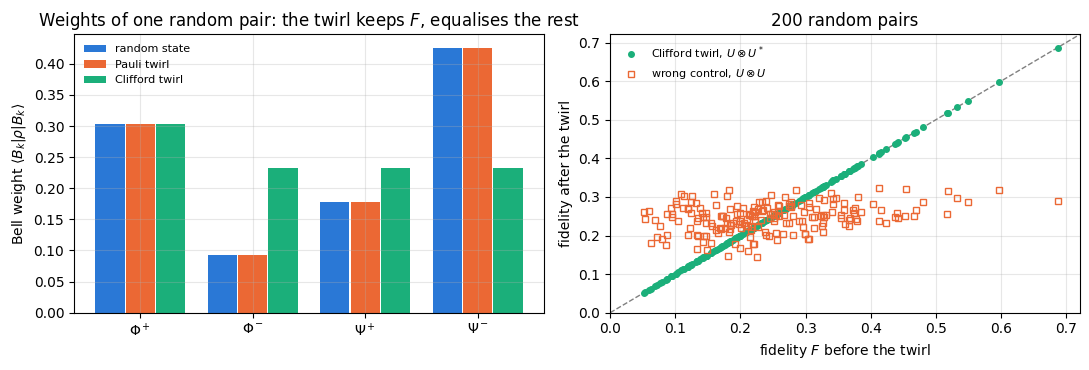

In [7]:
# ==============================================================================
# FIGURE: the twirl on one random state, and the fidelity before and after
# ==============================================================================
rho_ex = random_pair_state(key_for(1001))
stages = {"random state": bell_weights(rho_ex), "Pauli twirl": bell_weights(twirl(rho_ex, PAULIS)),
          "Clifford twirl": bell_weights(twirl(rho_ex, CLIFF24))}
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3.8))
xb = np.arange(4)
for i, (name, w) in enumerate(stages.items()):
    ax1.bar(xb + (i - 1) * 0.27, w, width=0.26, color=PALETTE[i], label=name)
ax1.set_xticks(xb, [r"$\Phi^+$", r"$\Phi^-$", r"$\Psi^+$", r"$\Psi^-$"])
ax1.set_ylabel(r"Bell weight $\langle B_k\vert\rho\vert B_k\rangle$")
ax1.set_title("Weights of one random pair: the twirl keeps $F$, equalises the rest")
ax1.legend(fontsize=8)
ax2.plot([0.0, 1.0], [0.0, 1.0], color="gray", lw=1, ls="--")
ax2.plot(F_in, F_twirl, MARKERS[0], color=PALETTE[2], ms=4, label=r"Clifford twirl, $U\otimes U^*$")
ax2.plot(F_in, F_wrong, MARKERS[1], color=PALETTE[1], ms=4, mfc="none", label=r"wrong control, $U\otimes U$")
ax2.set_xlabel("fidelity $F$ before the twirl"); ax2.set_ylabel("fidelity after the twirl")
lim = 1.05 * max(max(F_in), max(F_wrong))
ax2.set_xlim(0, lim); ax2.set_ylim(0, lim)
ax2.set_title("200 random pairs"); ax2.legend(fontsize=8, loc="upper left")
plt.tight_layout(); plt.show()

In the left panel the random state has four different Bell weights and, invisible here, coherences between them. The
Pauli twirl keeps the weights and removes the coherences; the Clifford twirl keeps the weight of $\vert\Phi^+\rangle$
and spreads the rest equally over the three error states. In the right panel the Clifford twirl leaves every
fidelity on the diagonal, and the $U\otimes U$ twirl scatters them.

### 5.3 What twirling does not do

Twirling fixes the **form** of the state and leaves its **quality** alone: a pair of fidelity $0.6$ becomes a Werner
pair of fidelity $0.6$, and Alice and Bob still do not know that number. Measuring it is the task of Section 9.
The twirl also relies on randomness that Eve does not know. Equation (9) describes the pair averaged over the unknown
gate. If Eve knew which gate $U$ was applied to a given pair, she could account for it, and for her the pair would be
the untwirled state rotated by a known gate, of whatever form she prepared. Each pair therefore needs a fresh random
gate, drawn from randomness that Alice
and Bob share privately and announce, if at all, only after the pairs have been measured or used. With these two
provisos, every statement made below for Werner pairs applies to any pair after a twirl.

## 6. Purification and Eve's share

### 6.1 Every mixed pair is part of a pure state

A mixed state of Alice and Bob is the reduced state of a pure state of a larger system (notebook 07, Section 4;
notebook 52, Section 6.2). If $\rho_{AB}=\sum_k\lambda_k\vert k\rangle\langle k\vert$ is its spectral decomposition,
then

$$\vert\Omega\rangle_{ABE}=\sum_k\sqrt{\lambda_k}\,\vert k\rangle_{AB}\,\vert e_k\rangle_E, \tag{10}$$

with orthonormal states $\vert e_k\rangle$ of a third system $E$, satisfies
$\mathrm{Tr}_E\vert\Omega\rangle\langle\Omega\vert=\rho_{AB}$, and is called a **purification** of $\rho_{AB}$. For a
Werner pair the eigenvectors are the four Bell states and the eigenvalues are $F$ and three times $e=(1-F)/3$, so $E$
needs four dimensions, two qubits. Physically, a pair becomes mixed because it became entangled with something else,
its environment, and Eq. (10) describes the pair together with that environment.

### 6.2 The worst case

Cryptography assumes the worst: **Eve holds the purification**. This is the strongest assumption one can make,
because every other system correlated with the pair can be obtained from $E$ by an operation on $E$ alone, so
whatever Eve could learn from any physical extension of the pair she can also learn from $E$. (Any extension can
itself be purified, and two purifications of the same $\rho_{AB}$ differ only by an isometry on the purifying
system; Eve applies that isometry to $E$ and discards the part she does not need.) Monogamy (notebook 52,
Section 6.2) gives the two limits: for $F=1$ the pair is pure and Eve is uncorrelated with it, and for $F<1$ the
bound of notebook 52, Eq. (11), leaves her a mutual information with the pair of at most
$2\big[h(F)+(1-F)\log_23\big]$ bits. Noise in a shared pair is information that may have leaked.

### 6.3 Eve's information about the key bits

How much does Eve learn about Alice's $Z$ outcome, the key bit of notebook 53, if she holds the purification of a
Bell-diagonal pair with weights $\lambda_{\Phi^+},\lambda_{\Phi^-},\lambda_{\Psi^+},\lambda_{\Psi^-}$? Write
Eq. (10) in the computational basis of Alice's qubit, with Eve's states $\vert e_{\Phi^\pm}\rangle$,
$\vert e_{\Psi^\pm}\rangle$:

$$\vert\Omega\rangle=\frac{1}{\sqrt2}\Big[\vert0\rangle_A\big(\vert0\rangle_B\vert u_+\rangle+\vert1\rangle_B
\vert w_+\rangle\big)+\vert1\rangle_A\big(\vert1\rangle_B\vert u_-\rangle+\vert0\rangle_B\vert w_-\rangle\big)\Big],$$

with $\vert u_\pm\rangle=\sqrt{\lambda_{\Phi^+}}\vert e_{\Phi^+}\rangle\pm\sqrt{\lambda_{\Phi^-}}\vert
e_{\Phi^-}\rangle$ and $\vert w_\pm\rangle=\sqrt{\lambda_{\Psi^+}}\vert e_{\Psi^+}\rangle\pm\sqrt{\lambda_{\Psi^-}}
\vert e_{\Psi^-}\rangle$. Alice's outcome $a$ is uniformly random. Given $a=0$, Eve's state is
$\rho_E^0=\vert u_+\rangle\langle u_+\vert+\vert w_+\rangle\langle w_+\vert$, two orthogonal vectors with squared
norms
$\lambda_{\Phi^+}+\lambda_{\Phi^-}=1-Q_Z$ and $\lambda_{\Psi^+}+\lambda_{\Psi^-}=Q_Z$, so its entropy is $h(Q_Z)$;
the same holds for $a=1$. Eve's average state is $\rho_E=\tfrac12(\rho_E^0+\rho_E^1)$, which has the eigenvalues
$\lambda_k$ because the $\vert e_k\rangle$ are orthonormal, so $S(\rho_E)=H(\lambda)$, the Shannon entropy of the four
weights. Eve's information about the key bit is the Holevo quantity of her two states (notebook 52, Section 9.1),

$$I(Z_A{:}E)=S(\rho_E)-\tfrac12\big[S(\rho_E^0)+S(\rho_E^1)\big]=H(\lambda)-h(Q_Z). \tag{11}$$

This is the quantity that enters the key rate. After Alice's measurement, Alice's bit and Eve's system are in the
state $\rho_{Z_AE}=\tfrac12\sum_a\vert a\rangle\langle a\vert\otimes\rho_E^a$, whose blocks are orthogonal, so
$S(\rho_{Z_AE})=1+\tfrac12\sum_aS(\rho_E^a)$. Notebook 53, Eq. (16), then gives
$H(Z_A\vert E)=S(\rho_{Z_AE})-S(\rho_E)=1-I(Z_A{:}E)$.

Bob knows $I(Z_A{:}Z_B)=1-h(Q_Z)$ about the same bit (notebook 50, Section 5). The Devetak–Winter rate of notebook 53,
Eq. (15), is the difference, and $h(Q_Z)$ cancels:

$$r=I(Z_A{:}Z_B)-I(Z_A{:}E)=1-H(\lambda). \tag{12}$$

Since $H(\lambda)=S(\rho_{AB})=S(\rho_E)$, Eq. (12) says that each pair yields one key bit minus the entropy of the
pair. Every bit of mixedness of the pair is a bit of entanglement that Eve may hold, and it costs one key bit.
For a Werner pair $H(\lambda)=h(F)+(1-F)\log_23$, by the grouping rule of the Shannon entropy. Equation (12) assumes
that Alice and Bob know all four weights. For a Bell-diagonal pair they can measure them: the error rates in the
three bases are $Q_Z=\lambda_{\Psi^+}+\lambda_{\Psi^-}$, $Q_X=\lambda_{\Phi^-}+\lambda_{\Psi^-}$ (notebook 53,
Eq. (14)) and $Q_Y=\lambda_{\Phi^-}+\lambda_{\Psi^+}$, the probability that the $Y$ outcomes agree, since
$\vert\Phi^+\rangle$ gives opposite ones; three equations fix three weights, and the fourth follows from the
normalisation. A protocol that tests all three bases is the six-state protocol of Bruß (1998). BB84 tests only $Z$
and $X$ and must assume the worst weights compatible with them. For $Q_Z=Q_X=Q$ these are independent bit and
phase errors, $\lambda=\big((1-Q)^2,\,Q(1-Q),\,Q(1-Q),\,Q^2\big)$, with $H(\lambda)=2h(Q)$, the largest value the two
constraints allow; Eq. (12) then gives the rate $1-2h(Q)$ of notebook 53.

The next cell builds the purification Eq. (10) on four qubits, $A$, $B$ and a two-qubit Eve, checks that it reduces
to the pair, computes $I(Z_A{:}E)=1-H(Z_A\vert E)$ from the engine's reduced density matrices for random
Bell-diagonal pairs and for Werner pairs, and compares with Eq. (11). Alice's $Z$ measurement turns the $8\times8$
matrix $\rho_{AE}$ into $\rho_{Z_AE}$ by setting to zero the two $4\times4$ blocks that are off-diagonal in her index,
which the code does with a mask. The wrong control is a pair with perfect $Z$
correlations and no other quantum correlation, weights $(\tfrac12,\tfrac12,0,0)$: Bob sees no bit errors at all, yet
Eve knows every key bit.

purification of the Werner pair F = 0.85: max |Tr_E - rho_W| = 1.7e-16, S(E) = 0.8476, H(lambda) = 0.8476


Eq. (11) on 100 random Bell-diagonal pairs: largest deviation 2.2e-14
Werner pairs: rate 1 - H(lambda) > 0 for F > 0.8107 (Q < 0.1262); BB84 bound 1 - 2h(Q) > 0 for F > 0.8350
wrong control, weights (1/2, 1/2, 0, 0): Q_Z = 0, Bob knows 1 bit, Eve knows I(Z_A:E) = 1.0000 bit


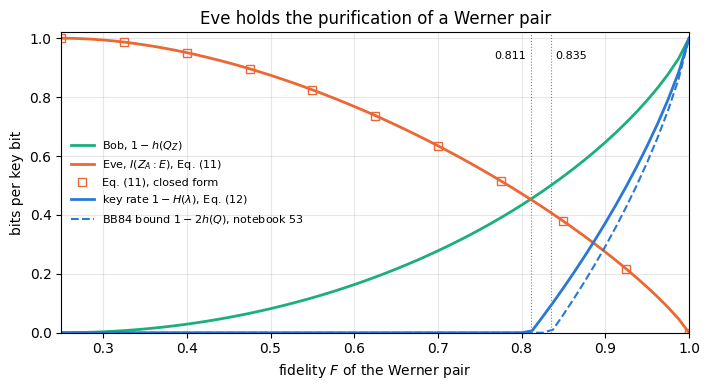

In [8]:
# ==============================================================================
# Eqs. (10)-(12): the purification held by Eve and her information about Z_A
# ==============================================================================
EVE_KETS = [product_state(s) for s in ("00", "01", "10", "11")]


def purify_bell_mixture(lam):
    """Eq. (10) for a Bell-diagonal pair: sum_k sqrt(lam_k) |B_k>_AB |k>_E, qubits A, B, E1, E2."""
    return sum(np.sqrt(l) * jnp.einsum("ab,cd->abcd", BELL[k], e) for l, k, e in zip(lam, BELL_KEYS, EVE_KETS))


@jax.jit
def eve_info_Z(omega):
    """I(Z_A : E) = 1 - H(Z_A|E) for the pure state omega of A, B, E1, E2, with H(Z_A|E) = S(rho_{Z_A E}) - S(rho_E)
    (notebook 53, Eq. (16)); measuring Z_A deletes the off-diagonal blocks of rho_{A E} in Alice's index."""
    r_ae = rdm(omega, [0, 2, 3])
    mask = jnp.kron(jnp.eye(2), jnp.ones((4, 4)))
    return 1.0 - (von_neumann_entropy(r_ae * mask) - von_neumann_entropy(rdm(omega, [2, 3])))


def eve_info_formula(lam):
    """Eq. (11): H(lambda) - h(Q_Z), Q_Z = lam_psi+ + lam_psi-."""
    return shannon(lam) - h2(lam[2] + lam[3])


omega_w = purify_bell_mixture([0.85, 0.05, 0.05, 0.05])
print(f"purification of the Werner pair F = 0.85: max |Tr_E - rho_W| = "
      f"{max_abs(rdm(omega_w, [0, 1]) - dm_matrix(werner(v_of_F(0.85)))):.1e}, "
      f"S(E) = {float(von_neumann_entropy(rdm(omega_w, [2, 3]))):.4f}, H(lambda) = {shannon([0.85] + [0.05] * 3):.4f}")
assert max_abs(rdm(omega_w, [0, 1]) - dm_matrix(werner(v_of_F(0.85)))) < TOL

rng_bd = numpy_rng(400)
worst = 0.0
for _ in range(100):
    lam = rng_bd.dirichlet(np.ones(4))
    worst = max(worst, abs(float(eve_info_Z(purify_bell_mixture(lam))) - eve_info_formula(lam)))
print(f"Eq. (11) on 100 random Bell-diagonal pairs: largest deviation {worst:.1e}")
assert worst < 1e-9

F_grid = np.linspace(0.25, 1.0, 61)
I_eve = np.array([float(eve_info_Z(purify_bell_mixture([F] + [(1 - F) / 3] * 3))) for F in F_grid])
I_bob = 1 - h2(2 * (1 - F_grid) / 3)                                     # Q_Z = 2(1-F)/3 for Werner pairs
rate_werner = I_bob - I_eve                                              # Eq. (12)
rate_bb84 = 1 - 2 * h2(2 * (1 - F_grid) / 3)                             # notebook 53, Eq. (19)
assert np.max(np.abs(rate_werner - (1 - np.array([shannon([F] + [(1 - F) / 3] * 3) for F in F_grid])))) < 1e-9

lo, hi = 0.6, 0.99                                                       # bisection: 1 - H(lambda) = 0
for _ in range(60):
    mid = 0.5 * (lo + hi)
    lo, hi = (lo, mid) if 1 - shannon([mid] + [(1 - mid) / 3] * 3) > 0 else (mid, hi)
F_HASH = hi
F_BB84 = F_of_v(1 - 2 * 0.110028)                                        # notebook 53, Eq. (21)
print(f"Werner pairs: rate 1 - H(lambda) > 0 for F > {F_HASH:.4f} (Q < {2 * (1 - F_HASH) / 3:.4f}); "
      f"BB84 bound 1 - 2h(Q) > 0 for F > {F_BB84:.4f}")
assert abs(F_HASH - 0.81071) < 1e-4

# wrong control: perfect Z correlations, nothing else
lam_cl = [0.5, 0.5, 0.0, 0.0]
I_cl = float(eve_info_Z(purify_bell_mixture(lam_cl)))
print(f"wrong control, weights (1/2, 1/2, 0, 0): Q_Z = 0, Bob knows 1 bit, Eve knows I(Z_A:E) = {I_cl:.4f} bit")
assert abs(I_cl - 1) < 1e-9

fig, ax = plt.subplots(figsize=(7.2, 4.0))
ax.plot(F_grid, I_bob, color=PALETTE[2], lw=2, label=r"Bob, $1-h(Q_Z)$")
ax.plot(F_grid, I_eve, color=PALETTE[1], lw=2, label=r"Eve, $I(Z_A{:}E)$, Eq. (11)")
ax.plot(F_grid[::6], [eve_info_formula([F] + [(1 - F) / 3] * 3) for F in F_grid[::6]], MARKERS[1],
        color=PALETTE[1], mfc="none", ms=6, label="Eq. (11), closed form")
ax.plot(F_grid, np.clip(rate_werner, 0, None), color=PALETTE[0], lw=2, label=r"key rate $1-H(\lambda)$, Eq. (12)")
ax.plot(F_grid, np.clip(rate_bb84, 0, None), color=PALETTE[0], lw=1.5, ls="--",
        label=r"BB84 bound $1-2h(Q)$, notebook 53")
ax.axvline(F_HASH, color="gray", lw=0.8, ls=":"); ax.axvline(F_BB84, color="gray", lw=0.8, ls=":")
ax.text(F_HASH - 0.005, 0.93, f"{F_HASH:.3f}", ha="right", fontsize=8)
ax.text(F_BB84 + 0.005, 0.93, f"{F_BB84:.3f}", ha="left", fontsize=8)
ax.set_xlabel(r"fidelity $F$ of the Werner pair"); ax.set_ylabel("bits per key bit")
ax.set_xlim(0.25, 1); ax.set_ylim(0, 1.02)
ax.set_title("Eve holds the purification of a Werner pair")
ax.legend(fontsize=8, loc="center left")
plt.tight_layout(); plt.show()

The purification reduces to the Werner pair, Eve's entropy equals $H(\lambda)$, and the engine's conditional
entropies reproduce Eq. (11) for random Bell-diagonal pairs to $10^{-9}$ or better. In the figure, Eve's
information falls from one bit at $F=1/4$ to zero at $F=1$, while Bob's rises. The key rate $1-H(\lambda)$ is
positive above $F=0.811$, an error rate $Q_Z=12.6\,\%$; the BB84 bound, which assumes the worst weights compatible
with
$Q_Z$ and $Q_X$, needs $F>0.835$. The wrong control is the classically correlated pair of notebook 53, Section 6.1,
seen
from Eve's side: no bit errors, and a complete copy of the key with Eve. A low error rate in one basis says nothing
about Eve; the weight of $\vert\Phi^+\rangle$, which needs tests in more than one basis, does.

## 7. Entanglement distillation

Suppose Alice and Bob share many Werner pairs of fidelity $F$. **Entanglement distillation** uses local operations
and classical communication to turn them into fewer pairs of higher fidelity. The first protocol is due to Bennett,
Brassard, Popescu, Schumacher, Smolin and Wootters (1996) and is called BBPSSW after them. It works on two pairs at a
time and rests on a single property of the CNOT gate.

### 7.1 The bilateral CNOT

Label each Bell state by two bits (Eq. (8)): the **parity** $p$, $0$ for $\Phi^\pm$ and $1$ for $\Psi^\pm$, which is
the outcome pattern of $ZZ=(-1)^p$; and the **phase** $f$, $0$ for $\Phi^+,\Psi^+$ and $1$ for $\Phi^-,\Psi^-$, with
$XX=(-1)^f$. Since $XX$ and $ZZ$ commute and their four pairs of eigenvalues differ, the two bits determine the Bell
state.

The CNOT gate with control $c$ and target $t$ transforms Pauli operators as

$$\mathrm{CNOT}\,Z_t\,\mathrm{CNOT}=Z_cZ_t,\qquad\mathrm{CNOT}\,X_c\,\mathrm{CNOT}=X_cX_t,\qquad
\mathrm{CNOT}\,Z_c\,\mathrm{CNOT}=Z_c,\qquad\mathrm{CNOT}\,X_t\,\mathrm{CNOT}=X_t: \tag{13}$$

a bit flip on the control is copied to the target, and a phase flip on the target is copied back to the control.
Each identity is a $4\times4$ matrix product. If a state $\vert\psi\rangle$ is an eigenstate of an operator $O$ with
eigenvalue $s$, then $U\vert\psi\rangle$ is an eigenstate of $UOU^\dagger$ with the same eigenvalue.

Take a **source** pair $(A_1,B_1)$ with bits $(p_1,f_1)$ and a **target** pair $(A_2,B_2)$ with bits $(p_2,f_2)$.
Alice applies a CNOT from $A_1$ to $A_2$, and Bob one from $B_1$ to $B_2$: the **bilateral CNOT**. Before the gates
the state is an eigenstate of $Z_{A_2}Z_{B_2}$ with eigenvalue $(-1)^{p_2}$; by Eq. (13), after the gates it is an
eigenstate of $Z_{A_1}Z_{A_2}Z_{B_1}Z_{B_2}$ with that eigenvalue. The source parity $Z_{A_1}Z_{B_1}=(-1)^{p_1}$ is
unchanged, so the target parity becomes $p_1\oplus p_2$. In the same way $X_{A_1}X_{B_1}$ becomes
$X_{A_1}X_{A_2}X_{B_1}X_{B_2}$ and $X_{A_2}X_{B_2}$ is unchanged, so the source phase becomes $f_1\oplus f_2$. Bell
pairs therefore stay Bell pairs, and their labels change as

$$(p_1,f_1)\,(p_2,f_2)\;\longrightarrow\;(p_1,\,f_1\oplus f_2)\,(p_1\oplus p_2,\,f_2). \tag{14}$$

The parity of the source is added to the target, and the phase of the target is added to the source, both modulo
two. The next cell checks Eq. (13) as matrix identities and Eq. (14) on all sixteen pairs of Bell states with the
engine, on four qubits ordered $A_1,B_1,A_2,B_2$.

In [9]:
# ==============================================================================
# Eqs. (13)-(14): the CNOT conjugation rules and the bilateral CNOT on Bell labels
# ==============================================================================
I4 = jnp.eye(4, dtype=CDTYPE)
rules = {"Z_t -> Z_c Z_t": (jnp.kron(I2, Z), jnp.kron(Z, Z)), "X_c -> X_c X_t": (jnp.kron(X, I2), jnp.kron(X, X)),
         "Z_c -> Z_c": (jnp.kron(Z, I2), jnp.kron(Z, I2)), "X_t -> X_t": (jnp.kron(I2, X), jnp.kron(I2, X))}
for name, (O, O_new) in rules.items():
    assert max_abs(CNOT @ O @ CNOT - O_new) < TOL                         # Eq. (13); CNOT = CNOT^dag
print("Eq. (13): all four conjugation rules hold")

A1, B1, A2, B2 = 0, 1, 2, 3


def bilateral_cnot(psi):
    """CNOT A1 -> A2 (Alice) and CNOT B1 -> B2 (Bob) on a state or density tensor whose first four axes are
    A1, B1, A2, B2."""
    return apply_gate(apply_gate(psi, CNOT, [A1, A2]), CNOT, [B1, B2])


label_of = {bits: k for bits, k in zip(BELL_BITS, BELL_KEYS)}
n_ok = 0
for (p1, f1), k1 in zip(BELL_BITS, BELL_KEYS):
    for (p2, f2), k2 in zip(BELL_BITS, BELL_KEYS):
        out = bilateral_cnot(jnp.einsum("ab,cd->abcd", BELL[k1], BELL[k2]))
        exp_src, exp_tgt = label_of[(p1, f1 ^ f2)], label_of[(p1 ^ p2, f2)]                # Eq. (14)
        expected = jnp.einsum("ab,cd->abcd", BELL[exp_src], BELL[exp_tgt])
        n_ok += int(abs(float(jnp.abs(jnp.vdot(expected, out)))) > 1 - 1e3 * TOL)       # equal up to a phase
print(f"Eq. (14): {n_ok} of 16 input pairs map to the predicted pair of Bell states")
assert n_ok == 16

Eq. (13): all four conjugation rules hold


Eq. (14): 16 of 16 input pairs map to the predicted pair of Bell states


All four rules hold, and every one of the sixteen inputs ends in the pair of Bell states that Eq. (14) predicts.

### 7.2 One recurrence step

The BBPSSW step consists of four operations on two Werner pairs of fidelity $F$.

1. Alice and Bob apply the bilateral CNOT, source pair to target pair.
2. Both measure their target qubit in the $Z$ basis and tell each other the result.
3. If the two results agree, they keep the source pair; otherwise they discard it. The target pair is always used up.
4. They twirl the kept pair back to Werner form (Section 5).

By Eq. (14) the target ends with parity $p_1\oplus p_2$, and the $Z$ outcomes of a Bell pair agree exactly when its
parity is zero. Agreement therefore means $p_1=p_2$: both pairs were of $\Phi$ type, or both of $\Psi$ type. A
Werner pair is $\vert\Phi^+\rangle$ with probability $F$ and each error state with probability $e=(1-F)/3$, so
both pairs are of $\Phi$ type with probability $(F+e)^2$ and both of $\Psi$ type with probability $(2e)^2$. The kept
source pair has parity $p_1$ and phase $f_1\oplus f_2$; it is $\vert\Phi^+\rangle$ when $p_1=p_2=0$ and $f_1=f_2$,
which means $\Phi^+\Phi^+$ or $\Phi^-\Phi^-$, with probability $F^2+e^2$. Hence

$$P_{\rm succ}=(F+e)^2+4e^2=F^2+2Fe+5e^2,\qquad F'=\frac{F^2+e^2}{F^2+2Fe+5e^2}. \tag{15}$$

The other three weights of the kept pair follow from the same table: $\Phi^-$ with $2Fe$ (from $\Phi^+\Phi^-$ and
$\Phi^-\Phi^+$), and $\Psi^+$ and $\Psi^-$ with $2e^2$ each, all divided by $P_{\rm succ}$. The kept pair is
Bell-diagonal but not of Werner form, which is why step 4 twirls it. The test catches a single bit flip, but two bit
flips pass it together, and phase errors are not tested at all: a phase error of the target is copied onto the kept
pair, which is the weight $2Fe$ of $\Phi^-$. The twirl of step 4 turns part of this weight into bit flips that the
next
step can catch.

### 7.3 The step on density tensors and shot by shot

The next cell implements the step twice. The first version works on the eight-index density tensor of two pairs:
`apply_gate_dm` applies the bilateral CNOT, the projectors $P_0\otimes P_0$ and $P_1\otimes P_1$ on $(A_2,B_2)$
select agreeing outcomes, the trace of what remains is $P_{\rm succ}$, and `rdm_dm` keeps the source pair. It works
for any input pair, not only Werner pairs. The second version runs the protocol as an experiment would: in each run
two pairs are prepared as $\vert\Phi^+\rangle$ hit by a random Pauli error on Alice's side with the Werner
probabilities $(F,e,e,e)$ (notebook 21, Section 10.1); the bilateral CNOT acts on the four-qubit state vector,
`measure_qubit` draws the two target outcomes, and the run succeeds if they agree. The function is compiled with
`jax.jit` and mapped over $4\times10^4$ independent keys with `jax.vmap`. The wrong control keeps the source pair
whatever the outcomes are: averaged over the target, the source then receives the target's phase errors without
any test. By Eq. (14) the source ends in $\vert\Phi^+\rangle$ if it was $\Phi^+$ and the target had phase $0$, or
it was $\Phi^-$ and the target had phase $1$, so its fidelity falls to $F(F+e)+e\cdot2e=F^2+Fe+2e^2<F$.

In [10]:
# ==============================================================================
# Eq. (15): one BBPSSW step on density tensors and shot by shot
# ==============================================================================
@jax.jit
def bbpssw_dm(pair1, pair2):
    """One recurrence step on two two-qubit density tensors (source, target). Returns (P_succ, kept source pair
    normalised, source pair without postselection). Qubit order A1, B1, A2, B2."""
    r = jnp.einsum("abAB,cdCD->abcdABCD", pair1, pair2)                  # all ket axes first, then all bra axes
    r = apply_gate_dm(apply_gate_dm(r, CNOT, [A1, A2]), CNOT, [B1, B2])   # bilateral CNOT
    kept = jnp.zeros((2, 2, 2, 2), dtype=CDTYPE)
    for P in PROJ:                                                       # outcomes agree: 00 or 11
        rm = apply_gate_dm(apply_gate_dm(r, P, [A2]), P, [B2])
        kept = kept + rdm_dm(rm, [A1, B1]).reshape(2, 2, 2, 2)
    p_succ = jnp.real(jnp.trace(dm_matrix(kept)))
    no_select = rdm_dm(r, [A1, B1]).reshape(2, 2, 2, 2)                   # wrong control: keep always
    return p_succ, kept / p_succ, no_select


def bbpssw_formula(F):
    """Eq. (15): (P_succ, F') and the four Bell weights of the kept pair."""
    e = (1 - F) / 3
    P = F**2 + 2 * F * e + 5 * e**2
    return P, (F**2 + e**2) / P, np.array([F**2 + e**2, 2 * F * e, 2 * e**2, 2 * e**2]) / P


ERRORS = jnp.stack([I2, Z, X, Y])                    # (sigma (x) 1)|Phi+> = Phi+, Phi-, Psi+, Psi- (up to a phase)


def bbpssw_shot(key, F):
    """One run of the step: two Werner pairs as random Pauli errors on |Phi+>, bilateral CNOT, Z measurement of
    the target pair. Returns (success flag, fidelity of the source pair after the run)."""
    k1, k2, k3, k4 = jax.random.split(key, 4)
    e = (1 - F) / 3
    logw = jnp.log(jnp.array([F, e, e, e]))
    psi = jnp.einsum("ab,cd->abcd", PHI_PLUS, PHI_PLUS)
    psi = apply_gate(psi, ERRORS[jax.random.categorical(k1, logw)], [A1])    # error on the source pair
    psi = apply_gate(psi, ERRORS[jax.random.categorical(k2, logw)], [A2])    # error on the target pair
    psi = bilateral_cnot(psi)
    ma, psi = measure_qubit(k3, psi, A2)
    mb, psi = measure_qubit(k4, psi, B2)
    F_src = jnp.real(jnp.vdot(PHI_PLUS.reshape(-1), rdm(psi, [A1, B1]) @ PHI_PLUS.reshape(-1)))
    return ma == mb, F_src


@partial(jax.jit, static_argnums=(1,))
def bbpssw_shots(key, n, F):
    return jax.vmap(lambda k: bbpssw_shot(k, F))(jax.random.split(key, n))


N_SHOTS = 40_000
print("   F   | P_succ: dm    Eq.15   shots          | F': dm      Eq.15   shots          | F no select (Eq.)")
for i, F in enumerate((0.55, 0.7, 0.85, 0.95)):
    P_dm, kept, nosel = bbpssw_dm(werner(v_of_F(F)), werner(v_of_F(F)))
    P_th, Fp_th, w_th = bbpssw_formula(F)
    ok, Fsrc = bbpssw_shots(key_for(500 + i), N_SHOTS, F)
    ok, Fsrc = np.asarray(ok), np.asarray(Fsrc)
    P_mc, Fp_mc = ok.mean(), Fsrc[ok].mean()
    se_P, se_F = np.sqrt(P_mc * (1 - P_mc) / N_SHOTS), np.sqrt(Fp_mc * (1 - Fp_mc) / ok.sum())
    e = (1 - F) / 3
    print(f" {F:.2f}  | {float(P_dm):.5f}  {P_th:.5f}  {P_mc:.4f}+-{se_P:.4f} | {fidelity(kept):.5f}  {Fp_th:.5f}  "
          f"{Fp_mc:.4f}+-{se_F:.4f} | {fidelity(nosel):.4f} ({F**2 + F * e + 2 * e**2:.4f})")
    assert abs(float(P_dm) - P_th) < TOL and np.max(np.abs(bell_weights(kept) - w_th)) < TOL
    assert max_abs(twirl(kept, CLIFF24) - werner(v_of_F(Fp_th))) < TOL                # step 4: back to Werner form
    assert abs(P_mc - P_th) < 5 * se_P and abs(Fp_mc - Fp_th) < 5 * se_F
    assert fidelity(nosel) < F and abs(fidelity(nosel) - (F**2 + F * e + 2 * e**2)) < TOL

   F   | P_succ: dm    Eq.15   shots          | F': dm      Eq.15   shots          | F no select (Eq.)


 0.55  | 0.58000  0.58000  0.5785+-0.0025 | 0.56034  0.56034  0.5588+-0.0033 | 0.4300 (0.4300)
 0.70  | 0.68000  0.68000  0.6800+-0.0023 | 0.73529  0.73529  0.7388+-0.0027 | 0.5800 (0.5800)
 0.85  | 0.82000  0.82000  0.8208+-0.0019 | 0.88415  0.88415  0.8861+-0.0018 | 0.7700 (0.7700)


 0.95  | 0.93556  0.93556  0.9374+-0.0012 | 0.96496  0.96496  0.9632+-0.0010 | 0.9189 (0.9189)


The density-tensor step reproduces Eq. (15) and the four weights of the kept pair to machine precision, the twirl
turns the kept pair into the Werner pair of fidelity $F'$, and $4\times10^4$ simulated runs agree with both within
their binomial error bars. At $F=0.7$ one step succeeds with probability $0.68$ and raises the fidelity to $0.735$;
at $F=0.95$ it reaches $0.965$. Without the test, keeping the source pair after the bilateral CNOT lowers its fidelity
at every $F$: the improvement comes from the postselection, and the CNOT alone only moves errors between the pairs.

### 7.4 Iterating the step

Repeating the step on pairs of improved pairs drives the fidelity up. With $e=(1-F)/3$, multiplying numerator and
denominator of Eq. (15) by nine gives $9(F^2+e^2)=10F^2-2F+1$ and $9P_{\rm succ}=8F^2-4F+5$, so

$$F'=\frac{10F^2-2F+1}{8F^2-4F+5},\qquad F'-F=\frac{(1-F)(2F-1)(4F-1)}{8F^2-4F+5}, \tag{16}$$

where the factorisation follows by expanding $(1-F)(2F-1)(4F-1)=-8F^3+14F^2-7F+1$, the numerator of $F'-F$. The
denominator is positive for all $F$. For $1/2<F<1$ all three factors of the numerator are positive, so **each step
raises the fidelity**. The map has fixed points at $F=1/4$, $1/2$ and $1$, and $F=1/2$ is the entanglement threshold
of Werner pairs: separable pairs cannot be distilled, and between $1/4$ and $1/2$ the step makes things worse.
Near $F=1$ the derivative of Eq. (16) is $2/3$, so the infidelity shrinks only by the factor $2/3$ per step,
$1-F'\approx\tfrac23(1-F)$.

The price is the number of pairs. Each step uses two pairs and keeps one with probability $P_{\rm succ}$, so after
$k$ steps an output pair costs on average

$$N_k=\frac{2\,N_{k-1}}{P_{{\rm succ},k}},\qquad N_0=1, \tag{17}$$

input pairs, at least $2^k$. The next cell iterates Eq. (16) and Eq. (17) for several starting fidelities, checks the
first five steps against the engine's density-tensor step followed by the twirl, and plots the map with the
iteration drawn as a staircase and the infidelity against the number of pairs consumed.

slope at F = 1: 0.6667 (2/3)
F = 0.7, five steps:  engine 0.73529 0.77317 0.81194 0.84947 0.88368
                      Eq. 16 0.73529 0.77317 0.81194 0.84947 0.88368
pairs per output pair, Eq. (17): 2.9 8.3 22.3 57.2 139.5
F0 = 0.6: F after 3 steps 0.6729, after 12 steps 0.95747; F < 0.99 after 12 steps
F0 = 0.7: F after 3 steps 0.8119, after 12 steps 0.99008; F >= 0.99 after 12 steps at a cost of 29562 pairs
F0 = 0.8: F after 3 steps 0.9045, after 12 steps 0.99660; F >= 0.99 after 10 steps at a cost of 2917 pairs
F0 = 0.9: F after 3 steps 0.9629, after 12 steps 0.99892; F >= 0.99 after 7 steps at a cost of 196 pairs


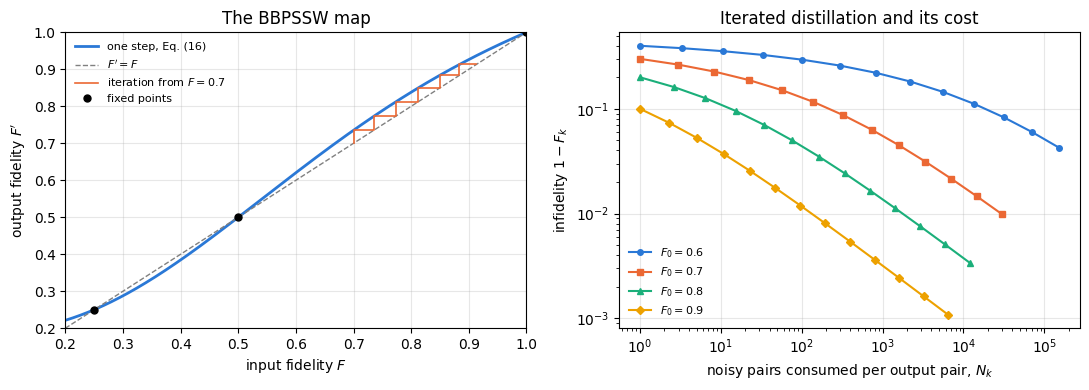

In [11]:
# ==============================================================================
# Eqs. (16)-(17): iterating the step, its fixed points and its cost
# ==============================================================================
def bbpssw_map(F):
    """Eq. (16), vectorised."""
    return (10 * F**2 - 2 * F + 1) / (8 * F**2 - 4 * F + 5)


def iterate(F0, steps):
    """Fidelities F_k and costs N_k (Eq. (17)) for k = 0..steps."""
    Fs, Ns = [F0], [1.0]
    for _ in range(steps):
        P = bbpssw_formula(Fs[-1])[0]
        Fs.append(bbpssw_map(Fs[-1])); Ns.append(2 * Ns[-1] / P)
    return np.array(Fs), np.array(Ns)


Fg = np.linspace(0.0, 1.0, 2001)
assert np.max(np.abs(bbpssw_map(Fg) - np.array([bbpssw_formula(F)[1] for F in Fg]))) < 1e-12        # Eq. (16)
assert np.max(np.abs(bbpssw_map(Fg) - Fg - (1 - Fg) * (2 * Fg - 1) * (4 * Fg - 1) / (8 * Fg**2 - 4 * Fg + 5))) < 1e-12
for Fp in (0.25, 0.5, 1.0):
    assert abs(bbpssw_map(Fp) - Fp) < 1e-12                                                       # fixed points
mid = (Fg > 0.5) & (Fg < 1)
low = (Fg > 0.25) & (Fg < 0.5)
assert np.all(bbpssw_map(Fg[mid]) > Fg[mid]) and np.all(bbpssw_map(Fg[low]) < Fg[low])
print(f"slope at F = 1: {(1 - bbpssw_map(1 - 1e-6)) / 1e-6:.4f} (2/3)")

# engine check of the iteration: density-tensor step + twirl, five times from F = 0.7
rho_it, F_eng = werner(v_of_F(0.7)), []
for _ in range(5):
    _, kept, _ = bbpssw_dm(rho_it, rho_it)
    rho_it = twirl(kept, CLIFF24)
    F_eng.append(fidelity(rho_it))
F_rec, N_rec = iterate(0.7, 5)
print("F = 0.7, five steps:  engine " + " ".join(f"{x:.5f}" for x in F_eng))
print("                      Eq. 16 " + " ".join(f"{x:.5f}" for x in F_rec[1:]))
print("pairs per output pair, Eq. (17): " + " ".join(f"{x:.1f}" for x in N_rec[1:]))
assert np.max(np.abs(np.array(F_eng) - F_rec[1:])) < 1e3 * TOL

STARTS = (0.6, 0.7, 0.8, 0.9)
runs = {F0: iterate(F0, 12) for F0 in STARTS}
for F0, (Fs, Ns) in runs.items():
    k99 = int(np.argmax(Fs >= 0.99)) if np.any(Fs >= 0.99) else None
    print(f"F0 = {F0}: F after 3 steps {Fs[3]:.4f}, after 12 steps {Fs[12]:.5f}; "
          + (f"F >= 0.99 after {k99} steps at a cost of {Ns[k99]:.0f} pairs" if k99 else "F < 0.99 after 12 steps"))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.0))
ax1.plot(Fg, bbpssw_map(Fg), color=PALETTE[0], lw=2, label="one step, Eq. (16)")
ax1.plot(Fg, Fg, color="gray", lw=1, ls="--", label="$F'=F$")
Fs, _ = runs[0.7]
stair_x, stair_y = [Fs[0]], [Fs[0]]
for a, b in zip(Fs[:6], Fs[1:7]):
    stair_x += [a, b]; stair_y += [b, b]
ax1.plot(stair_x, stair_y, color=PALETTE[1], lw=1.2, label="iteration from $F=0.7$")
ax1.plot([0.25, 0.5, 1.0], [0.25, 0.5, 1.0], "o", color="k", ms=5, label="fixed points")
ax1.set_xlim(0.2, 1.0); ax1.set_ylim(0.2, 1.0)
ax1.set_xlabel("input fidelity $F$"); ax1.set_ylabel("output fidelity $F'$")
ax1.set_title("The BBPSSW map"); ax1.legend(fontsize=8, loc="upper left")
for i, (F0, (Fs, Ns)) in enumerate(runs.items()):
    ax2.loglog(Ns, 1 - Fs, MARKERS[i] + "-", color=PALETTE[i], ms=4, label=f"$F_0={F0}$")
ax2.set_xlabel("noisy pairs consumed per output pair, $N_k$"); ax2.set_ylabel("infidelity $1-F_k$")
ax2.set_title("Iterated distillation and its cost"); ax2.legend(fontsize=8)
plt.tight_layout(); plt.show()

The engine's five steps from $F=0.7$ follow Eq. (16) to machine precision, and the slope at $F=1$ is $2/3$. In the
left panel the map lies above the diagonal between $1/2$ and $1$, and the staircase from $F=0.7$ climbs towards one in
ever smaller steps. The right panel shows the cost: from $F_0=0.9$, seven steps and about $200$ noisy pairs give one
pair of fidelity above $0.99$; from $F_0=0.8$ this takes ten steps and about $3000$ pairs, from $F_0=0.7$ twelve steps
and $3\times10^4$ pairs, and from $F_0=0.6$ twelve steps reach only $0.957$. Every step multiplies the
cost by at least two, while the infidelity shrinks by at most a constant factor, so the infidelity falls only as a
power of the cost.

### 7.5 Better protocols

Two weaknesses of BBPSSW are visible in Eq. (16): the twirl throws away the information about which error states are
present, and the slow convergence near $F=1$ follows from it. The protocol of Deutsch, Ekert, Jozsa, Macchiavello,
Popescu and Sanpera (1996) replaces the twirl by fixed local rotations before each bilateral CNOT and is much more
efficient: it works on pairs that are not of Werner form and reaches high fidelity with fewer pairs (Exercise 7).
For many pairs at once, Bennett, DiVincenzo, Smolin and Wootters (1996) introduced the **hashing** protocol, which
uses one-way classical communication and yields $1-S(\rho)$ good pairs per input pair from Bell-diagonal pairs with
entropy $S(\rho)$. For Werner pairs the yield is positive for $F>0.8107$. It is the same expression as the key rate
$1-H(\lambda)$ of Eq. (12): a perfect pair shared with nobody else yields a secret bit, so distilling pairs and
distilling a key from the same noisy pairs are closely related tasks. In practice recurrence steps first raise the
fidelity above this threshold, and hashing then finishes with a nonzero yield.

## 8. Quantum repeaters

### 8.1 Loss in optical fibre

Optical fibre absorbs and scatters light. The loss is quoted in decibels per kilometre: an attenuation of $\alpha$
dB/km means that the transmitted fraction over a length $L$ is

$$\eta(L)=10^{-\alpha L/10}. \tag{18}$$

A typical value for standard telecom fibre at a wavelength near $1550$ nm is $\alpha=0.2$ dB/km (Sangouard and
coauthors 2011), which gives
$\eta=10^{-2}$ over $100$ km and $\eta=10^{-10}$ over $500$ km. A classical signal is amplified every few tens of
kilometres, but an amplifier would copy an unknown quantum state, which no-cloning forbids (notebook 52, Section 4).
Pirandola, Laurenza, Ottaviani and Banchi (2017) proved that the number of secret-key bits, or of ebits, that any
protocol can distribute through a lossy channel of transmission $\eta$ without intermediate stations is at most

$$R_{\rm direct}(\eta)=-\log_2(1-\eta)\approx1.44\,\eta \tag{19}$$

per use of the channel, even with unlimited local resources and two-way classical communication. The rate of direct
transmission therefore falls exponentially with distance.

### 8.2 Swapping with noisy links

Entanglement swapping (Żukowski, Zeilinger, Horne and Ekert 1993; notebook 21, Sections 4–10) joins a pair $(A,R_1)$
and a pair $(R_2,B)$ into a pair $(A,B)$
by a Bell measurement at the middle node and a Pauli correction. With Werner links the visibilities multiply,

$$\rho_W(v_1),\ \rho_W(v_2)\ \xrightarrow{\ \text{swap}\ }\ \rho_W(v_1v_2),\qquad
F_{\rm out}=F_1F_2+\frac{(1-F_1)(1-F_2)}{3}, \tag{20}$$

as derived in notebook 21, Section 10.3, from the composition of two random Pauli errors. A chain of $n$ links swapped
without distillation ends with $v^n$, and notebook 21, Section 11, shows its exponential decay to a separable pair.
The next cell implements the swap on a four-qubit density tensor, summed over the four outcomes of the Bell
measurement with the correction applied, and checks Eq. (20); the function is reused in the repeater chain below.

In [12]:
# ==============================================================================
# Eq. (20): swapping two noisy links on a four-qubit density tensor
# ==============================================================================
@jax.jit
def swap_dm(link1, link2):
    """Pairs (0,1) and (2,3); Bell measurement on (1,2), correction Z^m1 X^m2 on qubit 3, sum over outcomes.
    Returns the density tensor of the outer pair (0,3)."""
    r = jnp.einsum("abAB,cdCD->abcdABCD", link1, link2)
    r = apply_gate_dm(apply_gate_dm(r, CNOT, [1, 2]), H, [1])
    out = jnp.zeros((2, 2, 2, 2), dtype=CDTYPE)
    for m1 in (0, 1):
        for m2 in (0, 1):
            rm = apply_gate_dm(apply_gate_dm(r, PROJ[m1], [1]), PROJ[m2], [2])
            corr = jnp.linalg.matrix_power(Z, m1) @ jnp.linalg.matrix_power(X, m2)
            out = out + rdm_dm(apply_gate_dm(rm, corr, [3]), [0, 3]).reshape(2, 2, 2, 2)
    return out


for v1, v2 in ((1.0, 1.0), (0.9, 0.8), (0.6, 0.5)):
    out = swap_dm(werner(v1), werner(v2))
    F1, F2 = F_of_v(v1), F_of_v(v2)
    print(f"v1 = {v1}, v2 = {v2}: max |rho_out - rho_W(v1 v2)| = {max_abs(out - werner(v1 * v2)):.1e}, "
          f"F_out = {fidelity(out):.4f} (Eq. 20: {F1 * F2 + (1 - F1) * (1 - F2) / 3:.4f})")
    assert max_abs(out - werner(v1 * v2)) < 10 * TOL

v1 = 1.0, v2 = 1.0: max |rho_out - rho_W(v1 v2)| = 2.2e-16, F_out = 1.0000 (Eq. 20: 1.0000)
v1 = 0.9, v2 = 0.8: max |rho_out - rho_W(v1 v2)| = 2.8e-16, F_out = 0.7900 (Eq. 20: 0.7900)
v1 = 0.6, v2 = 0.5: max |rho_out - rho_W(v1 v2)| = 1.1e-16, F_out = 0.4750 (Eq. 20: 0.4750)


The swapped pair is the Werner pair of visibility $v_1v_2$ in every case, with the fidelity of Eq. (20).

### 8.3 A toy repeater chain

A repeater of the type proposed by Briegel, Dür, Cirac and Zoller (1998) divides the line into $2^n$ segments and
works in $n$ **nesting levels**. At level zero each segment holds Werner pairs of fidelity $F_0$, produced and stored
in memories. At each level, neighbouring pairs are swapped into a pair over twice the distance, Eq. (20), and the
swapped pairs are distilled with $r$ rounds of BBPSSW, Eq. (15). Near $F=1$ the infidelity $\epsilon=1-F$ changes
simply: a swap of two equal pairs gives $1-F_{\rm out}\approx2\epsilon$, because $v^2\approx1-2(1-v)$ and $\epsilon$
is proportional to $1-v$, and each round of distillation multiplies the infidelity by $2/3$ (Section 7.4). One level
therefore maps

$$\epsilon\;\to\;2\left(\tfrac23\right)^r\epsilon : \tag{21}$$

without distillation the infidelity doubles at every level; one round per level still lets it grow by $4/3$; two
rounds make it shrink by $8/9$. The cost of a level is two pairs for the swap times $2/P_{\rm succ}$ for every round
of distillation.

The next cell runs this chain on density tensors with the engine: at each level `swap_dm` joins two copies of the
current pair, and `bbpssw_dm` followed by the Clifford twirl distils it $r$ times. It starts from $F_0=0.97$, uses
$r=0,1,2$, and goes up to five levels, $32$ segments. The pairs stay of Werner form throughout, so one copy of the
current pair represents all of them.

In [13]:
# ==============================================================================
# Eq. (21): a toy repeater chain of swapping and distillation on density tensors
# ==============================================================================
F0_CHAIN, LEVELS = 0.97, 5


def repeater_chain(F0, rounds, levels):
    """Fidelity and cost (elementary pairs per end-to-end pair) after each nesting level."""
    rho, cost, Fs, costs = werner(v_of_F(F0)), 1.0, [F0], [1.0]
    for _ in range(levels):
        rho, cost = swap_dm(rho, rho), 2 * cost                          # Eq. (20)
        for _ in range(rounds):
            p, kept, _ = bbpssw_dm(rho, rho)                             # Eq. (15)
            rho, cost = twirl(kept, CLIFF24), 2 * cost / float(p)
        Fs.append(fidelity(rho)); costs.append(cost)
    return np.array(Fs), np.array(costs)


chains = {r: repeater_chain(F0_CHAIN, r, LEVELS) for r in (0, 1, 2)}
print(f"F0 = {F0_CHAIN}; level n joins 2^n segments")
print(" r | F after levels 1..5                       | elementary pairs per end-to-end pair")
for r, (Fs, cs) in chains.items():
    print(f" {r} | " + " ".join(f"{x:.4f}" for x in Fs[1:]) + " | " + " ".join(f"{c:8.0f}" for c in cs[1:]))
# checks: no distillation follows v^(2^n); one round decays; two rounds hold the fidelity
Fs0 = chains[0][0]
assert np.max(np.abs(Fs0 - F_of_v(v_of_F(F0_CHAIN) ** (2.0 ** np.arange(LEVELS + 1))))) < 1e3 * TOL
assert np.all(np.diff(chains[1][0]) < 0) and chains[1][0][-1] > Fs0[-1]
assert np.all(chains[2][0][1:] >= F0_CHAIN - 0.005)
ratio = (1 - chains[2][0][2]) / (1 - chains[2][0][1])
print(f"infidelity ratio per level with r = 2: {ratio:.3f} (Eq. 21 near F = 1: 8/9 = {8 / 9:.3f}); "
      f"with r = 1: {(1 - chains[1][0][2]) / (1 - chains[1][0][1]):.3f} (4/3)")

F0 = 0.97; level n joins 2^n segments
 r | F after levels 1..5                       | elementary pairs per end-to-end pair
 0 | 0.9412 0.8870 0.7910 0.6403 0.4531 |        2        4        8       16       32
 1 | 0.9584 0.9416 0.9164 0.8772 0.8132 |        4       19       89      441     2369
 2 | 0.9711 0.9723 0.9735 0.9747 0.9759 |        9       83      753     6781    60723
infidelity ratio per level with r = 2: 0.960 (Eq. 21 near F = 1: 8/9 = 0.889); with r = 1: 1.405 (4/3)


Without distillation the end-to-end fidelity follows $v^{2^n}$ and falls to $0.45$ after five levels, a pair that is
no longer entangled. One round of distillation per level slows the decay, as Eq. (21) predicts with its factor $4/3$,
and two rounds stop it: the fidelity stays at about $F_0$ over $32$ segments, and even grows slowly, because the
per-level factor at $F_0=0.97$ is slightly below one. The measured ratio deviates from the limits $8/9$ and $4/3$
because $1-F=0.03$ is not yet small enough for Eq. (21) to be exact. The price is the cost column: two rounds
per level make one end-to-end pair cost about nine times more elementary pairs per level.

### 8.4 Rate against distance

How does the repeater compare with direct transmission? Consider a line of length $L$ cut into $2^n$ segments of
length $L_0=L/2^n$. In a **toy model**, every segment makes one attempt per time slot to create a pair, which
succeeds with probability $\eta(L_0)$, and successful pairs wait in perfect memories. All segments work in parallel,
so the line produces $2^n\eta(L_0)$ elementary pairs per time slot, and with $C_n$ elementary pairs per end-to-end
pair
from the chain above,

$$R_{\rm rep}(L)=\frac{2^n\,\eta(L/2^n)}{C_n} \tag{22}$$

end-to-end pairs of fidelity $F_n$ per time slot. The model ignores everything that makes real repeaters hard:
the time that pairs wait for their neighbours and the decoherence of the memories while they wait, probabilistic Bell
measurements, errors of the local gates, and the time needed to send the classical messages along the line. It shows
only the mechanism. Equation (22) contains $\eta(L/2^n)$ instead of $\eta(L)$: the loss acts on the short segments,
and the cost $C_n$ is paid in local operations. With a fixed segment length $L_0$ and $n=\log_2(L/L_0)$ levels, the
cost grows by a constant factor $c$ per level, $C_n=c^n=(L/L_0)^{\log_2c}$, so

$$R_{\rm rep}(L)=\eta(L_0)\,\Big(\frac{L}{L_0}\Big)^{1-\log_2c}, \tag{23}$$

a power law in $L$: the rate falls polynomially with distance instead of exponentially. The next cell evaluates
Eq. (22) with the costs of the two-round chain, for $2$, $4$, $8$ and $16$ segments, and Eq. (23) for $L_0=50$ km,
and compares them with the direct bound Eq. (19).

L = 100 km: eta = 1.0e-02, direct bound 1.450e-02 = 1.450 eta
L = 500 km: eta = 1.0e-10, direct bound 1.443e-10 = 1.443 eta


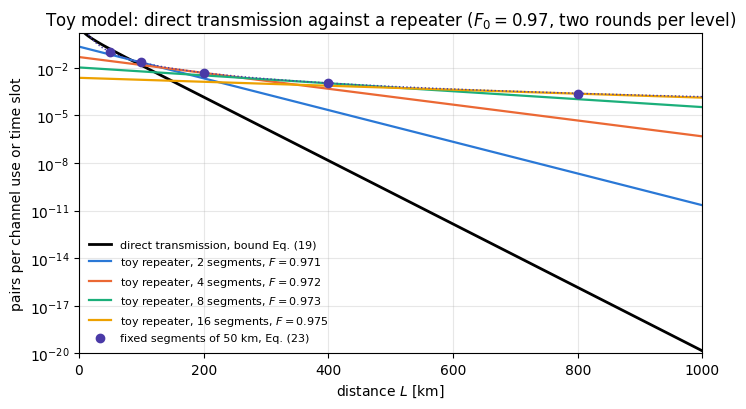

cost factor per level c = 8.95; Eq. (23): R ~ L^-2.16
 2 segments: the toy repeater beats the direct bound beyond L = 83 km
 4 segments: the toy repeater beats the direct bound beyond L = 99 km
 8 segments: the toy repeater beats the direct bound beyond L = 123 km
16 segments: the toy repeater beats the direct bound beyond L = 149 km
at L = 1000 km: direct 1.4e-20, 16 segments 1.3e-04


In [14]:
# ==============================================================================
# Eqs. (18)-(19), (22)-(23): direct transmission against the toy repeater
# ==============================================================================
ALPHA = 0.2                                                              # dB/km, a typical value at 1550 nm


def eta(L):
    """Eq. (18): transmission of L km of fibre."""
    return 10 ** (-ALPHA * np.asarray(L, dtype=float) / 10)


def R_direct(L):
    """Eq. (19): -log2(1 - eta), evaluated with log1p so that tiny eta are accurate."""
    return -np.log1p(-eta(L)) / np.log(2)


for L in (100, 500):
    print(f"L = {L} km: eta = {eta(L):.1e}, direct bound {R_direct(L):.3e} = {R_direct(L) / eta(L):.3f} eta")
assert abs(eta(100) - 1e-2) < 1e-12 and abs(eta(500) - 1e-10) < 1e-20
assert abs(R_direct(500) / eta(500) - 1 / np.log(2)) < 1e-6                 # 1.44 eta for small eta

F_ch, C_ch = chains[2]
c_level = C_ch[-1] / C_ch[-2]                                            # cost factor per level (r = 2)
L_axis = np.linspace(1, 1000, 500)
L0 = 50.0
fig, ax = plt.subplots(figsize=(7.4, 4.2))
ax.semilogy(L_axis, R_direct(L_axis), color="k", lw=2, label="direct transmission, bound Eq. (19)")
cross = {}
for i, n in enumerate((1, 2, 3, 4)):
    R_rep = 2**n * eta(L_axis / 2**n) / C_ch[n]                          # Eq. (22)
    ax.semilogy(L_axis, R_rep, color=PALETTE[i], lw=1.6, label=f"toy repeater, {2**n} segments, $F={F_ch[n]:.3f}$")
    cross[n] = L_axis[np.argmax(R_rep > R_direct(L_axis))]
Ls = L0 * 2.0 ** np.arange(0, 5)
R_fixed = eta(L0) * (Ls / L0) / C_ch[:5]                                 # Eq. (22) with L/2^n = L0
ax.semilogy(Ls, R_fixed, "o", color=PALETTE[5], ms=6, label=f"fixed segments of {L0:.0f} km, Eq. (23)")
ax.semilogy(L_axis, eta(L0) * (L_axis / L0) ** (1 - np.log2(c_level)), color=PALETTE[5], lw=1, ls=":")
ax.set_ylim(1e-20, 1.5); ax.set_xlim(0, 1000)
ax.set_xlabel("distance $L$ [km]"); ax.set_ylabel("pairs per channel use or time slot")
ax.set_title(f"Toy model: direct transmission against a repeater ($F_0={F0_CHAIN}$, two rounds per level)")
ax.legend(fontsize=8, loc="lower left")
plt.tight_layout(); plt.show()
print(f"cost factor per level c = {c_level:.2f}; Eq. (23): R ~ L^{1 - np.log2(c_level):.2f}")
for n, Lc in cross.items():
    print(f"{2**n:2d} segments: the toy repeater beats the direct bound beyond L = {Lc:.0f} km")
print(f"at L = 1000 km: direct {R_direct(1000):.1e}, 16 segments {16 * eta(1000 / 16) / C_ch[4]:.1e}")
assert 16 * eta(1000 / 16) / C_ch[4] > 1e10 * R_direct(1000)
assert np.allclose(C_ch[1:5], c_level ** np.arange(1, 5), rtol=0.1)            # C_n ~ c^n, the premise of Eq. (23)

Direct transmission falls by a factor of ten every $50$ km. Each repeater curve falls with the slope of its
segment length, $2^n$ times more slowly, and starts lower, because of the cost $C_n$; it overtakes direct
transmission at a crossover distance that grows with the number of segments, from about $80$ km for two segments
to about $150$ km for sixteen. At $1000$ km the direct bound is of order $10^{-20}$ pairs per use, against about
$10^{-4}$ for the sixteen-segment toy repeater. With segments of fixed length the points lie close to the power law of
Eq. (23), since the cost factor per level changes only from $9.1$ to $9.0$; the power law is a straight line on a
logarithmic distance axis and appears curved here because the distance axis is linear. The
numbers depend on every simplification of the model; the change from exponential to polynomial decay is the
robust part. The comparison is also only indicative because the repeater delivers pairs of fidelity $F_n<1$, while
the bound of Eq. (19) counts perfect pairs. Briegel and coauthors showed that their nested scheme tolerates errors of
the local operations at the
percent level, with an overhead in time that grows only polynomially and a number of locally controlled qubits that
grows only logarithmically with the distance. Repeaters that take memory times, loss in the local operations and
probabilistic swapping into account are reviewed by Sangouard, Simon, de Riedmatten and Gisin (2011).

## 9. Certifying pairs before use

### 9.1 Fidelity from three local correlations

The pairs that reach Alice and Bob may come from an untrusted source. Before using them they need a statement such
as "the pairs we keep have fidelity at least $F_{\min}$ with $\vert\Phi^+\rangle$, except with probability $\delta$".
A measured pair is destroyed, so they can only test some of the pairs and draw conclusions about the others. And
they are far apart, so a test must use local measurements and a classical channel.

The fidelity can be written in terms of local correlations. By Eq. (8), $\vert\Phi^+\rangle$ is the only Bell state
with $ZZ=+1$ and $XX=+1$. The projector onto the eigenvalue $+1$ of $ZZ$ is $\tfrac12(\mathbb 1+ZZ)$, and similarly
for $XX$. The two operators commute, so the projector onto their common eigenvalue $+1$ is the product,

$$\vert\Phi^+\rangle\langle\Phi^+\vert=\frac{\mathbb 1+ZZ}{2}\cdot\frac{\mathbb 1+XX}{2}
=\frac14\big(\mathbb 1+ZZ+XX+(ZX)\otimes(ZX)\big)=\frac14\big(\mathbb 1+XX-YY+ZZ\big), \tag{24}$$

because $ZX=iY$ and therefore $(ZX)\otimes(ZX)=-Y\otimes Y$. Taking the expectation value in $\rho$,

$$F=\frac{1+\langle XX\rangle-\langle YY\rangle+\langle ZZ\rangle}{4}. \tag{25}$$

To estimate $\langle XX\rangle$, Alice and Bob both measure $X$ on the same pair, multiply their two $\pm1$ outcomes
over the classical channel, and average over many pairs; the same for $YY$ and $ZZ$. A pair can be measured in one
setting only, so the test pairs are split at random into three groups. In terms of error rates, with $Q_Z$ and $Q_X$
the probabilities of unequal outcomes and $Q_Y$ the probability of equal $Y$ outcomes as in Section 6.3,
$\langle ZZ\rangle=1-2Q_Z$, $\langle XX\rangle=1-2Q_X$, $\langle YY\rangle=-(1-2Q_Y)$, and Eq. (25) becomes

$$F=1-\frac{Q_X+Q_Y+Q_Z}{2}. \tag{26}$$

For a Werner pair all three rates are $(1-v)/2$, and Eq. (26) returns $F=(1+3v)/4$. The next cell checks Eqs. (24)
and (25) on random two-qubit states with the engine's `expect_pauli_string_dm`. The wrong control is a source that
emits $\vert\Phi^+\rangle$ with probability $0.9$ and the product state $\vert00\rangle$ otherwise: its $Z$
correlations are perfect, so a test in $Z$ alone sees no error, while Eq. (25) finds $F=0.95$; a source of
$\vert00\rangle$ and $\vert11\rangle$ mixed in equal parts passes the $Z$ test as well, with $F=1/2$ and no
entanglement.

In [15]:
# ==============================================================================
# Eqs. (24)-(26): fidelity from the three correlations XX, YY, ZZ
# ==============================================================================
proj_pauli = (jnp.eye(4) + jnp.kron(X, X) - jnp.kron(Y, Y) + jnp.kron(Z, Z)) / 4
assert max_abs(proj_pauli - jnp.outer(phi_vec, phi_vec.conj())) < TOL        # Eq. (24)


def correlations(rho):
    """(<XX>, <YY>, <ZZ>) of a two-qubit density tensor."""
    return np.array([float(expect_pauli_string_dm(rho, s)) for s in ("XX", "YY", "ZZ")])


def fidelity_from_corr(c):
    """Eq. (25)."""
    return (1 + c[0] - c[1] + c[2]) / 4


worst = 0.0
for j in range(100):
    rho = random_pair_state(key_for(600 + j))
    worst = max(worst, abs(fidelity_from_corr(correlations(rho)) - fidelity(rho)))
print(f"Eq. (24) holds as a matrix identity; Eq. (25) on 100 random states: largest deviation {worst:.1e}")
assert worst < TOL

rho_faulty = 0.9 * to_dm(PHI_PLUS) + 0.1 * to_dm(product_state("00"))
rho_classical = 0.5 * to_dm(product_state("00")) + 0.5 * to_dm(product_state("11"))
for name, rho in (("0.9 Phi+ + 0.1 |00>", rho_faulty), ("(|00><00| + |11><11|)/2", rho_classical)):
    c = correlations(rho)
    neg = float(negativity(rho, [0])[0])
    print(f"{name:26s}: <XX> = {c[0]:+.2f}, <YY> = {c[1]:+.2f}, <ZZ> = {c[2]:+.2f}; Q_Z = {(1 - c[2]) / 2:.2f}; "
          f"F from Eq. (25) = {fidelity_from_corr(c):.3f}, direct {fidelity(rho):.3f}; negativity {neg:.3f}")
assert abs(fidelity_from_corr(correlations(rho_faulty)) - 0.95) < TOL
assert abs(fidelity_from_corr(correlations(rho_classical)) - 0.5) < TOL
assert abs(float(negativity(rho_classical, [0])[0])) < TOL

Eq. (24) holds as a matrix identity; Eq. (25) on 100 random states: largest deviation 2.2e-16
0.9 Phi+ + 0.1 |00>       : <XX> = +0.90, <YY> = -0.90, <ZZ> = +1.00; Q_Z = 0.00; F from Eq. (25) = 0.950, direct 0.950; negativity 0.450
(|00><00| + |11><11|)/2   : <XX> = +0.00, <YY> = +0.00, <ZZ> = +1.00; Q_Z = 0.00; F from Eq. (25) = 0.500, direct 0.500; negativity 0.000


Equation (24) holds as a $4\times4$ identity, and Eq. (25) gives the fidelity of every random state to machine
precision. Both faulty sources have $Q_Z=0$. The first has $F=0.95$, and its $\vert00\rangle$ admixture shows up only
in the $X$ and $Y$ correlations; the second has $F=1/2$ and zero negativity, so it is not entangled at all, and only
the $X$ and $Y$ tests expose it. Tests in all three bases are needed.

### 9.2 A confidence bound for independent pairs

Suppose first that the pairs are **independent and identically distributed** (i.i.d.): each is in the same state
$\rho$, independently of the others. The product of Alice's and Bob's outcomes in the $XX$ setting is then a random
variable $s\in\{-1,+1\}$ with mean $\langle XX\rangle$. Hoeffding (1963) proved that the average $\bar s$ of $m$
independent random variables with values in an interval $[a,b]$ and common mean $\langle s\rangle$ exceeds
$\langle s\rangle+t$ with probability at most $e^{-2mt^2/(b-a)^2}$, and the same holds for
$\bar s\leq\langle s\rangle-t$. For $[a,b]=[-1,1]$,

$$P\big(\bar s-\langle s\rangle\geq t\big)\leq e^{-mt^2/2},\qquad
P\big(\langle s\rangle-\bar s\geq t\big)\leq e^{-mt^2/2}. \tag{27}$$

This is a bound for every distribution of the variables, with no Gaussian approximation. Alice and Bob measure $m$
pairs in each of the three settings and require all three estimates to lie within $t$ of their means on both sides.
These are six bad events, and the probability that at least one of them occurs is at most the sum of their six
probabilities, so each is allowed the probability $\delta/6$. Setting $e^{-mt^2/2}=\delta/6$ gives
$t=\sqrt{2\ln(6/\delta)/m}$, and an error of at most $t$ in each correlation changes Eq. (25) by at most $3t/4$.
With probability at least $1-\delta$, therefore,

$$F\;\geq\;\hat F-\frac34\sqrt{\frac{2\ln(6/\delta)}{m}}, \tag{28}$$

where $\hat F$ is Eq. (25) evaluated with the measured averages. For $m=2000$ pairs per setting and $\delta=0.01$ the
margin is $0.060$. The next cell simulates this test $10^5$ times on i.i.d. Werner pairs with $v=0.9$, $F=0.925$: the
engine gives the three correlations, and the number of $+1$ products in each setting is drawn from the binomial
distribution, which is the exact distribution of the counts for i.i.d. pairs. It records how often the true $F$ lies
below the bound of Eq. (28) for several values of $\delta$. It compares this with a bound built on the Gaussian
approximation, $\hat F-z_{1-\delta}\,\hat\sigma_F$. Here $z_{1-\delta}$ is the value that a standard normal variable
exceeds with probability $\delta$ ($2.33$ for $\delta=0.01$, `norm.ppf(1 - delta)` in SciPy). A product $s=\pm1$
with mean $c$ has the variance $1-c^2$, so the estimated standard error of $\hat F$ in Eq. (25) is
$\hat\sigma_F=\tfrac14\big[\sum_i(1-\hat c_i^{\,2})/m\big]^{1/2}$, summed over the three settings.

In [16]:
# ==============================================================================
# Eqs. (27)-(28): Hoeffding's bound on the fidelity, tested by Monte Carlo on i.i.d. Werner pairs
# ==============================================================================
from scipy.stats import norm, hypergeom

V_TEST, M_PER_SETTING, REPS = 0.9, 2000, 100_000
rho_test = werner(V_TEST)
c_true = correlations(rho_test)
F_true = fidelity(rho_test)
rng_h = numpy_rng(700)
counts = rng_h.binomial(M_PER_SETTING, (1 + c_true) / 2, size=(REPS, 3))      # number of +1 products per setting
c_hat = 2 * counts / M_PER_SETTING - 1
F_hat = (1 + c_hat[:, 0] - c_hat[:, 1] + c_hat[:, 2]) / 4                     # Eq. (25)
sigma_F = np.sqrt(np.sum(1 - c_hat**2, axis=1) / M_PER_SETTING) / 4           # standard error of F_hat


def hoeffding_margin(delta, m):
    """Eq. (28): (3/4) sqrt(2 ln(6/delta)/m)."""
    return 0.75 * np.sqrt(2 * np.log(6 / delta) / m)


DELTAS = np.array([0.3, 0.1, 0.03, 0.01, 0.003])
fail_h = np.array([np.mean(F_true < F_hat - hoeffding_margin(d, M_PER_SETTING)) for d in DELTAS])
fail_g = np.array([np.mean(F_true < F_hat - norm.ppf(1 - d) * sigma_F) for d in DELTAS])
print(f"Werner pairs v = {V_TEST}: F = {F_true:.4f}; m = {M_PER_SETTING} per setting; mean F_hat = {F_hat.mean():.4f}")
print(f"margin at delta = 0.01: {hoeffding_margin(0.01, M_PER_SETTING):.4f}; certified F >= "
      f"{F_true - hoeffding_margin(0.01, M_PER_SETTING):.3f} for a typical F_hat")
print("  delta | Hoeffding margin | failure rate (Hoeffding) | Gaussian margin | failure rate (Gaussian)")
for d, fh, fg in zip(DELTAS, fail_h, fail_g):
    print(f"  {d:.3f} |      {hoeffding_margin(d, M_PER_SETTING):.4f}      |        {fh:.1e}           |"
          f"     {norm.ppf(1 - d) * sigma_F.mean():.4f}      |      {fg:.4f}")
assert abs(hoeffding_margin(0.01, 2000) - 0.0600) < 1e-3
assert np.all(fail_h <= DELTAS)
assert np.all(fail_g < 2 * DELTAS) and np.all(fail_g[-2:] > DELTAS[-2:] + 5 * np.sqrt(DELTAS[-2:] / REPS))
sigma_true = np.sqrt(np.sum(1 - c_true**2) / M_PER_SETTING) / 4                # the exact standard error of F_hat
fail_true = np.array([np.mean(F_true < F_hat - norm.ppf(1 - d) * sigma_true) for d in DELTAS])
print("Gaussian margin with the exact standard error, failure rate: " + "  ".join(f"{x:.4f}" for x in fail_true))
assert np.all(fail_true[-2:] < DELTAS[-2:])

Werner pairs v = 0.9: F = 0.9250; m = 2000 per setting; mean F_hat = 0.9250
margin at delta = 0.01: 0.0600; certified F >= 0.865 for a typical F_hat
  delta | Hoeffding margin | failure rate (Hoeffding) | Gaussian margin | failure rate (Gaussian)
  0.300 |      0.0410      |        0.0e+00           |     0.0022      |      0.3082
  0.100 |      0.0480      |        0.0e+00           |     0.0054      |      0.1101
  0.030 |      0.0546      |        0.0e+00           |     0.0079      |      0.0335
  0.010 |      0.0600      |        0.0e+00           |     0.0098      |      0.0141
  0.003 |      0.0654      |        0.0e+00           |     0.0116      |      0.0044
Gaussian margin with the exact standard error, failure rate: 0.3082  0.0987  0.0295  0.0087  0.0026


The bound of Eq. (28) never failed in $10^5$ simulated tests at any of the listed values of $\delta$: Hoeffding's
inequality holds for every distribution and is therefore conservative for this one, with a margin of about fourteen
standard errors of $\hat F$ at $\delta=0.01$. The Gaussian bound is six times narrower and fails at roughly the
nominal rate for large $\delta$, but at $\delta=0.01$ and $0.003$ it fails in $1.4\,\%$ and $0.44\,\%$ of the
tests, more often than promised. The cause is the estimated standard error: a sample with few $-1$ products gives a
high $\hat F$ and at the same time a small $\hat\sigma_F$, so the margin is narrowest exactly when the estimate is too
high. With the exact standard error of $\hat F$ the Gaussian margin keeps its promise at $\delta=0.01$ and $0.003$,
as the last printed line shows. Equation (28) is a theorem for any $m$, the Gaussian bound an approximation. Both assume i.i.d.
pairs, which an adversarial source need not provide.

### 9.3 An adversarial source and random sampling

If Eve controls the source, nothing forces the pairs to be independent or identical. She may send different states
in different rounds, and she may entangle the pairs with one another and with her own memory. Suppose she knew which
pairs Alice and Bob were going to test. She would send perfect pairs to those positions and useless pairs everywhere
else; every test would pass, and every kept pair would be bad. The defence is to choose the test positions uniformly
at
random **after** the pairs have been delivered, and to keep the choice secret until then. Eve then cannot treat tested
and untested pairs differently.

A bound without any independence follows from the random choice alone. Think of each of the $N=n+k$ pairs as carrying
a hidden flag, set if a test of that pair would fail, and let an unknown fraction $\lambda$ of the flags be set,
arranged in any way Eve likes. Alice and Bob reveal $k$ flags chosen uniformly at random without replacement and
observe the fraction $\hat\lambda$. Hoeffding (1963) also proved that sampling without replacement from a finite
population obeys the same bound as independent sampling; for flags in $\{0,1\}$, an interval of length one, it
reads $P(\lambda-\hat\lambda\geq s)\leq e^{-2ks^2}$. The flags of the $n$ untested pairs have the fraction
$\lambda_{\rm rem}$, and counting the set flags gives $N\lambda=k\hat\lambda+n\lambda_{\rm rem}$, hence
$\lambda_{\rm rem}-\hat\lambda=\tfrac Nn(\lambda-\hat\lambda)$. With $s=\tfrac nN\mu$,

$$P\big(\lambda_{\rm rem}\geq\hat\lambda+\mu\big)\leq\exp\!\Big(-2k\,\frac{n^2}{N^2}\,\mu^2\Big). \tag{29}$$

No independence between the pairs was assumed: the randomness comes entirely from Alice's and Bob's choice of the
sample. Sharper versions of this bound, due to Serfling (1974), are used in practice. In the language of
Section 9.1, a test fails when the outcomes are unequal in $XX$ or $ZZ$ or equal in $YY$. If each test pair is
also given one of the three settings at random, the failure fraction is $\lambda=(Q_X+Q_Y+Q_Z)/3$, and Eq. (26)
reads $F=1-\tfrac32\lambda$. A bound on the failure fraction of the kept pairs is therefore a bound on their
fidelity, $F_{\rm rem}\geq1-\tfrac32(\hat\lambda+\mu)$, in this classical picture; Section 9.4 says what changes
for quantum pairs.

The next cell tests Eq. (29) against an adversary who plants $b$ bad pairs among $N=1000$, of which $k=200$ are
tested, with a margin $\mu=0.1$, where the bound is $e^{-2.56}=0.077$. For each $b$ it runs $2\times10^4$ random
samples, each the first $k$ entries of a random permutation of the positions (`np.argsort` of uniform random
numbers), and
counts how often the untested pairs contain more than $\hat\lambda+\mu$ bad ones; the exact probability follows from
the hypergeometric distribution of the number of bad pairs in the sample. The wrong control tests fixed positions,
the first $k$ pairs, which Eve knows and leaves clean.

bound of Eq. (29): 7.73e-02
random sampling: largest failure rate 6.9e-03 (simulated), 7.1e-03 (exact), at b = 500 bad pairs
fixed test positions: failure with certainty for 100 <= b <= 950 bad pairs


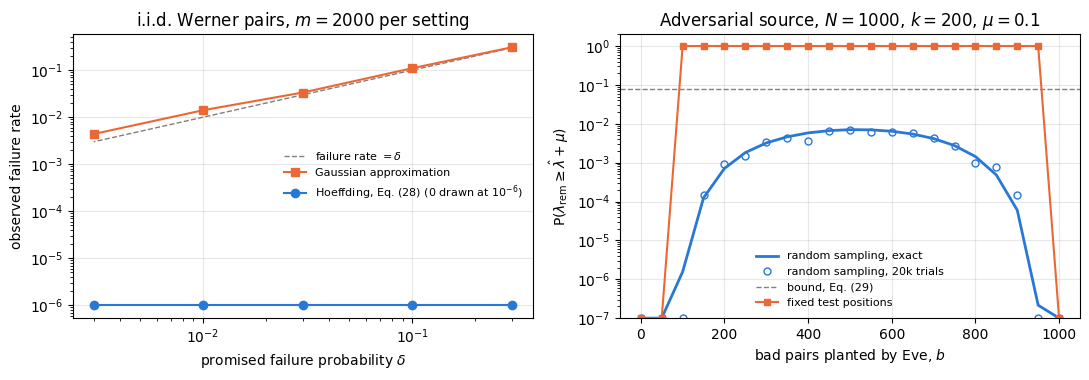

In [17]:
# ==============================================================================
# Eq. (29): an adversary who plants bad pairs, random sampling against fixed test positions
# ==============================================================================
N_PAIRS, K_TEST, MU, TRIALS = 1000, 200, 0.1, 20_000
N_KEEP = N_PAIRS - K_TEST
bound_29 = np.exp(-2 * K_TEST * (N_KEEP / N_PAIRS) ** 2 * MU**2)
rng_s = numpy_rng(800)
b_values = np.arange(0, N_PAIRS + 1, 50)
fail_random, fail_exact, fail_fixed = [], [], []
for b in b_values:
    flags = np.zeros(N_PAIRS, dtype=bool)
    flags[np.r_[K_TEST:N_PAIRS, 0:K_TEST][:b]] = True                     # Eve fills the untested positions first
    # random sampling: a fresh uniformly random test set in each trial (chosen after delivery)
    tested = np.argsort(rng_s.random((TRIALS, N_PAIRS)), axis=1)[:, :K_TEST]
    bad_in_test = flags[tested].sum(axis=1)
    lam_hat, lam_rem = bad_in_test / K_TEST, (b - bad_in_test) / N_KEEP
    fail_random.append(np.mean(lam_rem >= lam_hat + MU))
    # exact: X ~ Hypergeom(N, b, k); failure iff (b - X)/n - X/k >= mu
    x = np.arange(0, min(b, K_TEST) + 1)
    pmf = hypergeom(N_PAIRS, b, K_TEST).pmf(x)
    fail_exact.append(float(pmf[(b - x) / N_KEEP - x / K_TEST >= MU - 1e-12].sum()))
    # wrong control: the first K_TEST positions are always tested; Eve leaves them clean
    lam_hat_fix, lam_rem_fix = flags[:K_TEST].mean(), flags[K_TEST:].mean()
    fail_fixed.append(float(lam_rem_fix >= lam_hat_fix + MU - 1e-12))
fail_random, fail_exact = np.array(fail_random), np.array(fail_exact)
i_max = int(np.argmax(fail_exact))
print(f"bound of Eq. (29): {bound_29:.2e}")
print(f"random sampling: largest failure rate {fail_random.max():.1e} (simulated), {fail_exact.max():.1e} (exact), "
      f"at b = {b_values[i_max]} bad pairs")
fixed_bad = b_values[np.array(fail_fixed) == 1.0]
print(f"fixed test positions: failure with certainty for {fixed_bad.min()} <= b <= {fixed_bad.max()} bad pairs")
assert np.all(fail_exact <= bound_29) and np.all(fail_random <= bound_29 + 5 * np.sqrt(bound_29 / TRIALS))
assert np.max(np.abs(fail_random - fail_exact)) < 5 * np.sqrt(bound_29 / TRIALS) + 1e-4
assert fail_fixed[2] == 1.0 and fail_exact.max() > 1e-3

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3.9))
ax1.loglog(DELTAS, DELTAS, color="gray", lw=1, ls="--", label=r"failure rate $=\delta$")
ax1.loglog(DELTAS, np.maximum(fail_g, 1e-6), MARKERS[1] + "-", color=PALETTE[1], label="Gaussian approximation")
ax1.loglog(DELTAS, np.maximum(fail_h, 1e-6), MARKERS[0] + "-", color=PALETTE[0],
           label=r"Hoeffding, Eq. (28) (0 drawn at $10^{-6}$)")
ax1.set_xlabel(r"promised failure probability $\delta$"); ax1.set_ylabel("observed failure rate")
ax1.set_title(f"i.i.d. Werner pairs, $m={M_PER_SETTING}$ per setting"); ax1.legend(fontsize=8, loc="center right")
ax2.semilogy(b_values, np.maximum(fail_exact, 1e-7), color=PALETTE[0], lw=2, label="random sampling, exact")
ax2.semilogy(b_values, np.maximum(fail_random, 1e-7), MARKERS[0], color=PALETTE[0], mfc="none", ms=5,
             label=f"random sampling, {TRIALS // 1000}k trials")
ax2.axhline(bound_29, color="gray", ls="--", lw=1, label="bound, Eq. (29)")
ax2.semilogy(b_values, np.maximum(fail_fixed, 1e-7), "s-", color=PALETTE[1], ms=4, label="fixed test positions")
ax2.set_ylim(1e-7, 2)
ax2.set_xlabel("bad pairs planted by Eve, $b$"); ax2.set_ylabel(r"P($\lambda_{\rm rem}\geq\hat\lambda+\mu$)")
ax2.set_title(f"Adversarial source, $N={N_PAIRS}$, $k={K_TEST}$, $\\mu={MU}$")
ax2.legend(fontsize=8, loc="lower center")
plt.tight_layout(); plt.show()

In the left panel the Gaussian bound fails at about the promised rate and somewhat more often for small $\delta$, and
the Hoeffding bound did not fail at all. In the
right panel, with random sampling, the probability that the kept pairs are worse than the test suggests by more
than $\mu$ stays below the bound of Eq. (29) for every number of planted pairs. It is largest, $7\times10^{-3}$, when
half of the pairs are bad, where the sampling fluctuations are largest, and it vanishes when almost none or almost
all pairs are bad; the simulation agrees with the exact hypergeometric values, and the bound is about ten times
larger than the worst case. With fixed test positions Eve wins with certainty as soon as her bad pairs make up a
fraction $\mu$ of the kept ones, $b\geq80$ (from $b=100$ on the grid of the figure). Up to $b=800$ the test reports
$\hat\lambda=0$ while every bad pair is
kept; beyond that all kept pairs are bad and the test sees only the overflow, until almost every pair is bad. The
same statistics with a different order of events gives no protection at all.

### 9.4 Sampling bounds for quantum pairs

The flag picture treats each pair as carrying a definite answer to the test. For quantum pairs this is not true: the
outcome of an untested pair is not defined until someone measures it, a pair measured in $Z$ reveals nothing about
its $X$ correlation, and Eve may entangle all pairs with each other. Rigorous proofs handle this by choosing, for
each test pair, both the position and the measurement setting at random, and by arguing that the untested pairs
**could** have been measured in the same way, so that the statistics of the hypothetical measurement on the kept pairs
obey a sampling bound of the form of Eq. (29). Takeuchi, Mantri, Morimae, Mizutani and Fitzsimons (2019), for
example, verify multi-qubit graph states in this way: they measure stabilizers on a random subset of the delivered
copies, sampled without replacement, and use Serfling's inequality to bound the fidelity of a copy that was not
tested, without assuming that the copies are independent or identical. The cost is the same as here: high confidence
about the untested pairs needs many test
pairs. After the test, a twirl of the kept pairs (Section 5) brings them to Werner form, and the test
supplies the one number, $F$, that the twirl leaves unknown.

## 10. Key takeaways

* **Werner pairs are the standard model of noisy pairs.** $\rho_W(v)=v\vert\Phi^+\rangle\langle\Phi^+\vert+
  (1-v)\mathbb 1/4$ has fidelity $F=(1+3v)/4$ and is entangled for $v>1/3$; depolarising both halves multiplies the
  visibilities, Eq. (4).
* **Teleportation through a Werner pair is the depolarising channel** $\mathcal D_v$, Eq. (5), by linearity; a
  Bell-diagonal pair of another form gives an anisotropic channel.
* **Twirling brings every pair to Werner form with the same fidelity.** $(U\otimes U^*)\vert\Phi^+\rangle=
  \vert\Phi^+\rangle$; Pauli gates delete the Bell-basis coherences and a cyclic Clifford gate equalises the error
  weights, Eqs. (6)–(9). The twirl needs fresh randomness unknown to Eve, and it does not reveal $F$.
* **Eve holds the purification in the worst case.** For a Bell-diagonal pair she knows $H(\lambda)-h(Q_Z)$ about each
  key bit, and the key rate is $1-H(\lambda)$, positive for Werner pairs above $F=0.811$, Eqs. (11)–(12).
* **The bilateral CNOT compares parities.** One BBPSSW step keeps the source pair when the target outcomes agree and
  raises the fidelity to $F'=(10F^2-2F+1)/(8F^2-4F+5)$ for $1/2<F<1$, Eqs. (14)–(16), at the cost of at least two
  pairs per step, Eq. (17). The step was run on density tensors and shot by shot.
* **Loss makes direct transmission exponentially slow**, at most $-\log_2(1-\eta)$ pairs or key bits per use of a
  fibre of transmission $\eta=10^{-\alpha L/10}$, Eqs. (18)–(19). Swapping multiplies visibilities, Eq. (20); with
  two rounds of BBPSSW per nesting level the toy repeater keeps its fidelity and its rate falls only as a power of
  the distance, Eqs. (21)–(23).
* **Certification is statistical.** Three local correlations give $F$, Eq. (25); Hoeffding's inequality gives a bound
  valid with probability $1-\delta$ for i.i.d. pairs, Eq. (28); against an adversarial source the test positions
  must be chosen at random after delivery, and then a sampling bound holds without any independence, Eq. (29).

## 11. Exercises

1. ★ **A Werner pair.** A Werner pair has $v=0.8$. Find its fidelity, the $Z$ error rate, the teleportation fidelity
   for a pure input and whether it is entangled. Both halves of $\vert\Phi^+\rangle$ are depolarised with $v=0.9$
   each: what are $v$ and $F$ of the result? Check with `apply_kraus_dm` and `fidelity`.
2. ★ **One step by hand.** Apply one BBPSSW step to $F=0.75$ with Eq. (15). How many steps of Eq. (16) take $F=0.75$
   above $0.95$, and how many noisy pairs does one output pair then cost?
3. ★★ **Twirling the singlet.** What does the twirl of Eq. (9) produce from $\vert\Psi^-\rangle$? Which value of $v$
   is that, and why is it outside $[0,1]$? Check with `twirl(to_dm(BELL["psi-"]), CLIFF24)`.
4. ★★ **A separable Werner pair.** Show that $\tfrac16\sum_a\vert a\rangle\langle a\vert\otimes\vert a^*\rangle
   \langle a^*\vert=\rho_W(1/3)$, where the sum runs over the six eigenstates of $X$, $Y$ and $Z$ and $\vert
   a^*\rangle$
   has complex-conjugated amplitudes. Use $\vert a\rangle\langle a\vert=\tfrac12(\mathbb 1+\mathbf n\cdot
   \boldsymbol\sigma)$ and Eq. (24). Why does this prove that $\rho_W(v)$ is separable for all $v\leq1/3$? Verify the
   identity numerically with `product_state`.
5. ★★ **Sample size.** How many pairs per setting give a fidelity margin of at most $0.0075$ with $\delta=10^{-6}$ in
   Eq. (28)? A test gives $\langle XX\rangle=0.82$, $\langle YY\rangle=-0.80$, $\langle ZZ\rangle=0.90$: what is
   $\hat F$, and is the pair entangled if these values are exact?
6. ★★ **The singlet in Pauli form.** Write $\vert\Psi^-\rangle\langle\Psi^-\vert$ in the form of Eq. (24), and check
   it numerically. Which correlations must a test measure to certify a source of singlets?
7. ★★★ **A faster protocol (extend the code).** Modify `bbpssw_dm` into the protocol of Deutsch and coauthors:
   before the bilateral CNOT, Alice applies `rx(np.pi / 2)` to both of her qubits and Bob `rx(-np.pi / 2)` to both of
   his, and there is no twirl after the step. Starting from the Werner pair with $F=0.7$, iterate both protocols six
   times and compare the fidelities and the costs. Why does the absence of the twirl help?
8. ★★★ **The repeater threshold (physics).** With two rounds of BBPSSW per nesting level, find the elementary
   fidelity $F_0$ at which one level of `repeater_chain` returns exactly $F_0$. What happens to the end-to-end
   fidelity over many levels for $F_0$ slightly above and slightly below this value? Relate your answer to
   Eq. (21).

*Check values.* 1: $F=0.85$, $Q=0.10$, teleportation fidelity $0.90$, entangled; two halves give $v=0.81$,
$F=0.8575$. 2: $e=1/12$, $P_{\rm succ}=0.7222$, $F'=41/52=0.7885$; Eq. (16) gives $0.7885,0.8270,0.8635,0.8959,
0.9231,0.9446,0.9610$, so seven steps reach $0.961$, at a cost of about $480$ pairs by Eq. (17). 3: $F=0$, so
$v=-1/3$ and the result is $\tfrac13(\mathbb 1-\vert\Phi^+\rangle\langle\Phi^+\vert)$, the equal mixture of the three
error states; Eq. (2) defines a state for $-1/3\leq v\leq1$, and the physical origin of Section 3 covers only
$v\geq0$. 4: complex conjugation changes $Y$ into $-Y$, so $\vert a^*\rangle\langle a^*\vert=\tfrac12(\mathbb 1+
n_xX-n_yY+n_zZ)$; the terms linear in $\mathbf n$ cancel between $\pm\mathbf n$, and the average of the products is
$\tfrac14[\mathbb 1+\tfrac13(XX-YY+ZZ)]=\rho_W(1/3)$ by Eq. (24); for $v<1/3$ mix it with the separable state
$\mathbb 1/4$. 5: $3t/4\leq0.0075$ needs $t\leq0.01$ and $m=2\ln(6\times10^6)/10^{-4}=3.1\times10^5$ pairs per
setting; $\hat F=0.88$, entangled because $F>1/2$ (a separable state twirls into a separable Werner pair with the same
$F$, which has $v\leq1/3$). 6: $\vert\Psi^-\rangle\langle\Psi^-\vert=\tfrac14(\mathbb 1-XX-YY-ZZ)$; all three
correlations. 7: BBPSSW gives $0.7353, 0.7732, 0.8119, 0.8495, 0.8837, 0.9130$ at a cost of $326$ pairs, the protocol
of Deutsch and coauthors $0.7353, 0.8459, 0.9344, 0.9720, 0.9970, 0.9998$ at a cost of $227$ pairs; without the
twirl the step keeps the information about which error states remain, and the rotations exchange the roles of the
error types from step to step, so that errors of every type are eventually tested. 8: $F_0\approx0.956$; this
fixed point is unstable: above it the fidelity grows with every level, below it the fidelity decays,
because the factor $2(2/3)^2=8/9$ of Eq. (21) holds only near $F=1$ and the map of a level is weaker at lower $F$.

## 12. Chapter 14 in one paragraph

The chapter began with Shannon's question of how much information a noisy channel carries (notebook 50) and with
the classical answer to secrecy, the one-time pad, which needs a secret key as long as the message (notebook 51).
Quantum mechanics changes the situation through three rules derived in notebook 52: unknown states cannot be copied,
gaining information disturbs them, and entanglement is monogamous. Notebook 53 turned these rules into quantum key
distribution, in which the error rate that Alice and Bob observe bounds what Eve can know, and the secret key rate
$1-2h(Q)$ follows from an uncertainty relation. This notebook supplied the resource that the entanglement-based
protocols consume, real entangled pairs: Werner pairs as their model, twirling to bring any pair into that form,
distillation to make few good pairs out of many noisy ones, repeaters to carry them across distances that loss
would otherwise forbid, and statistical certification to trust them when the source is not trusted. Every step was
a protocol of local operations and classical communication acting on shared quantum states, and every step was
simulated with the same engine.

## References

* R. F. Werner, *Quantum states with Einstein-Podolsky-Rosen correlations admitting a hidden-variable model*,
  Phys. Rev. A **40**, 4277 (1989), doi:10.1103/PhysRevA.40.4277 — the Werner states.
* A. Peres, *Separability criterion for density matrices*, Phys. Rev. Lett. **77**, 1413 (1996),
  doi:10.1103/PhysRevLett.77.1413 — the partial-transpose test for entanglement.
* M. Horodecki, P. Horodecki and R. Horodecki, *Separability of mixed states: necessary and sufficient conditions*,
  Phys. Lett. A **223**, 1 (1996), doi:10.1016/S0375-9601(96)00706-2 — the partial-transpose test is also sufficient
  for two qubits.
* S. Massar and S. Popescu, *Optimal extraction of information from finite quantum ensembles*, Phys. Rev. Lett.
  **74**, 1259 (1995), doi:10.1103/PhysRevLett.74.1259 — the best fidelity of estimating an unknown qubit from one
copy,
  $2/3$.
* C. H. Bennett, G. Brassard, S. Popescu, B. Schumacher, J. A. Smolin and W. K. Wootters, *Purification of noisy
  entanglement and faithful teleportation via noisy channels*, Phys. Rev. Lett. **76**, 722 (1996),
  doi:10.1103/PhysRevLett.76.722 — the recurrence distillation protocol with the bilateral CNOT and random bilateral
  rotations.
* C. H. Bennett, D. P. DiVincenzo, J. A. Smolin and W. K. Wootters, *Mixed-state entanglement and quantum error
  correction*, Phys. Rev. A **54**, 3824 (1996), doi:10.1103/PhysRevA.54.3824 — the hashing protocol with
  yield $1-S$, positive for Werner pairs with $F>0.8107$, and the relation between distillation and quantum error
  correction.
* D. Deutsch, A. Ekert, R. Jozsa, C. Macchiavello, S. Popescu and A. Sanpera, *Quantum privacy amplification and the
  security of quantum cryptography over noisy channels*, Phys. Rev. Lett. **77**, 2818 (1996),
  doi:10.1103/PhysRevLett.77.2818 — a more efficient distillation protocol with local rotations in place of the
  twirl, and its use for secure key distribution.
* D. Bruß, *Optimal eavesdropping in quantum cryptography with six states*, Phys. Rev. Lett. **81**, 3018 (1998),
  doi:10.1103/PhysRevLett.81.3018 — the six-state protocol.
* M. Żukowski, A. Zeilinger, M. A. Horne and A. K. Ekert, *"Event-ready-detectors" Bell experiment via entanglement
  swapping*, Phys. Rev. Lett. **71**, 4287 (1993), doi:10.1103/PhysRevLett.71.4287 — entanglement swapping.
* H.-J. Briegel, W. Dür, J. I. Cirac and P. Zoller, *Quantum repeaters: the role of imperfect local operations in
  quantum communication*, Phys. Rev. Lett. **81**, 5932 (1998), doi:10.1103/PhysRevLett.81.5932 — the quantum repeater
  with nested purification, with a polynomial overhead in time and a logarithmic overhead in locally controlled
  particles.
* S. Pirandola, R. Laurenza, C. Ottaviani and L. Banchi, *Fundamental limits of repeaterless quantum communications*,
  Nat. Commun. **8**, 15043 (2017), doi:10.1038/ncomms15043 — the bound $-\log_2(1-\eta)$ for a lossy channel without
  repeaters.
* N. Sangouard, C. Simon, H. de Riedmatten and N. Gisin, *Quantum repeaters based on atomic ensembles and linear
  optics*, Rev. Mod. Phys. **83**, 33 (2011), doi:10.1103/RevModPhys.83.33 — review of practical repeater
  architectures; fibre loss of 0.2 dB/km near 1550 nm.
* W. Hoeffding, *Probability inequalities for sums of bounded random variables*, J. Am. Stat. Assoc. **58**, 13
  (1963), doi:10.1080/01621459.1963.10500830 — the exponential bounds for independent bounded variables and for
  sampling without replacement.
* R. J. Serfling, *Probability inequalities for the sum in sampling without replacement*, Ann. Statist. **2**, 39
  (1974), doi:10.1214/aos/1176342611 — sharper bounds for sampling without replacement.
* Y. Takeuchi, A. Mantri, T. Morimae, A. Mizutani and J. F. Fitzsimons, *Resource-efficient verification of quantum
  computing using Serfling's bound*, npj Quantum Inf. **5**, 27 (2019), doi:10.1038/s41534-019-0142-2 — verification
  of graph states by random sampling without an i.i.d. assumption.

---
Marcin Płodzień, PhD

**Citation:** M. Płodzień, *Quantum Many-Body Simulation: from a single spin to quantum machine learning* (2026), https://marcinplodzien.github.io/quantum-many-body-simulation/